## Load notebook

### Python modules

In [1]:
# standard libs
import numpy as np
import pandas as pd
from scipy import sparse
import lmfit as lm
from tqdm import tqdm
import io, sys, importlib
from contextlib import redirect_stdout

# matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.rcParams['font.size'], plt.rcParams['axes.labelsize'] = 14, 18

# XPCS library
sys.path.append('/mnt/data/XPCS_library/')

import ID10tools as ID10
from ID10tools import Nx, Ny, Npx
importlib.reload(ID10)
ID10.set_version('v2')

import XPCStools as XPCS
from XPCStools import E2lambda, lambda2E, theta2Q, Q2theta, decorrelation_f
importlib.reload(XPCS)
XPCS.set_beamline('ID10')

import COSMICRAYtools as COSMIC
importlib.reload(COSMIC)
COSMIC.set_beamline('ID10')

#### EXPERIMENTAL VARIABLES ####
XPCS.set_expvar(1350, 1350, 7.1)
ID10.Nfmax_dense_file = 2000
ID10.Nfmax_sparse_file = 5000
################################

###### FOLDER PATHS ######
from folder_paths import *
##########################

### Functions

In [2]:
def plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True):

    print("Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan")
    global model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan  

    if t1_fit is None: t1_fit = 0
    if t2_fit is None: t2_fit = 1e100
    
    g2fit = pd.DataFrame(columns=['Q', 'dQ', 'tau', 'dtau', 'dtau%', 'beta', 'dbeta', 'dbeta%', 'c', 'dc', 'dc%', 'y0', 'dy0', 'dy%', 'redchi2'])

    # FIT DATA
    # time-mask 4 fitting
    tmask = (t1_fit<g2[0])*(g2[0]<t2_fit)
    x, y, dy =  g2[0][tmask], g2[1][tmask], g2[2][tmask]
    
    # compute and save the fit
    fit = model.fit(y, params, t=x, method='least_squares', weights=1/dy)
    g2fit.loc[0] = [Q_notebook, dQ_notebook,
                    fit.params['tau'].value, fit.params['tau'].stderr, fit.params['tau'].stderr/fit.params['tau'].value*100,
                    fit.params['beta'].value, fit.params['beta'].stderr, fit.params['beta'].stderr/fit.params['beta'].value*100,
                    fit.params['c'].value, fit.params['c'].stderr, fit.params['c'].stderr/fit.params['c'].value*100,
                    fit.params['y0'].value, fit.params['y0'].stderr, fit.params['y0'].stderr/fit.params['y0'].value*100,
                    fit.redchi,]
    if save: g2fit.to_csv(f"{g2fit4damaged_vGeO2_folder}g2fit-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", index=False)
    
    # print fit report
    display(g2fit)

    # PLOT FIT AND RESIDUALS IN SUBPLOTS
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.05}, sharex=True)

    # Main fit plot
    ax1.scatter(g2[0], g2[1], s=1, c='C0')
    t_mt, g2_mt, dg2_mt = XPCS.get_g2mt_fromling2(itime, g2[1], g2[2])
    ax1.errorbar(t_mt, g2_mt, yerr=dg2_mt, fmt = 'o', c='C1')

    xfit = np.arange(np.min(g2[0]), np.max(g2[0]), 1e-2)
    yfit = fit.eval(t=xfit)
    ax1.plot(xfit, yfit, c='black', linestyle='--')
    if t1_fit != 0:
        ax1.axvline(t1_fit, color='red', linestyle='--')
    if t2_fit != 1e100:
        ax1.axvline(t2_fit, color='red', linestyle='--')
    ax1.set_ylabel('g2')
    ax1.set_xscale('log')
    ax1.set_ylim(bottom=1, top=np.max(g2[1] + g2[2]))

    # Residuals plot
    residuals = (g2[1] - fit.eval(t=g2[0])) / g2[2]
    ax2.scatter(g2[0], residuals, color='C0')
    ax2.axhline(0, color='black', linestyle='--')
    ax2.set_xlabel('t [s]')
    ax2.set_ylabel('Res/$\\sigma$')
    ax2.set_xscale('log')

    plt.setp(ax1.get_xticklabels(), visible=False)

    return fig, ax1, ax2


In [3]:
from sparse_dot_mkl import dot_product_mkl
import time 

def bin_data(e4m_data, mask = None, Nfi=None, Nff=None, Lbin=None, bin2dense=False):
    '''
    Compute the G2t matrix from the e4m, properly masked with the matrix mask.

    Parameters
    ----------
    e4m_data: sparse.csr_matrix
        Sparse matrix of the e4m detector data
    mask: np.array
        Mask of the e4m detector
    Nfi: int
        First frame to consider
    Nff: int
        Last frame to consider
    Lbin: int
        Binning factor for the frames
    MKL_library: boolean
        If True, use the MKL library for the matrix multiplication
    
    Returns
    -------
    G2t: np.array
        G2t matrix
        
    '''

    if Nfi == None: Nfi = 0
    if Nff == None: Nff = e4m_data.shape[0]
    if Lbin == None: Lbin = 1

    #  LOAD DATA
    t0 = time.time()
    print('Loading frames ...')
    if (Nfi!=0) or (Nff!=e4m_data.shape[0]): Itp = e4m_data[Nfi:Nff]
    else : Itp = e4m_data
    # convert to float32
    if Itp.dtype != np.float32:
        Itp = Itp.astype(np.float32)
    print('Done! (elapsed time =', round(time.time()-t0, 2), 's)')

    # BIN DATA
    if Lbin != 1:
        t0 = time.time()
        print('Binning frames (Lbin = '+str(Lbin)+', using MKL library) ...')
        Itp = (Itp[:Itp.shape[0]//Lbin*Lbin]) # throw the last frames 
        BIN_matrix = sparse.csr_array((np.ones(Itp.shape[0]), (np.arange(Itp.shape[0])//Lbin, np.arange(Itp.shape[0]))), dtype=np.float32)
        Itp = dot_product_mkl(BIN_matrix, Itp, dense=bin2dense)
        print('Done! (elapsed time =', round(time.time()-t0, 2), 's)')
        print('\t | '+str(Itp.shape[0])+' frames X '+str(Itp.shape[1])+' pixels')
        if isinstance(Itp, sparse.sparray):
            print('\t | sparsity = {:.2e}'.format(Itp.data.size/(Itp.shape[0]*Itp.shape[1])))
            print('\t | memory usage (sparse.csr_array @ '+str(Itp.dtype)+') =', round((Itp.data.nbytes+Itp.indices.nbytes+Itp.indptr.nbytes)/1024**3,3), 'GB')
        else:
            print('\t | memory usage (np.array @ '+str(Itp.dtype)+') =', round(Itp.nbytes/1024**3,3), 'GB')

    #  MASK DATA
    t0 = time.time()
    if mask is not None:
        print('Masking data ...')
        Itp = Itp[:,mask]
        print('Done! (elapsed time =', round(time.time()-t0, 2), 's)')
        print('\t | '+str(Itp.shape[0])+' frames X '+str(Itp.shape[1])+' pixels')
        if isinstance(Itp, sparse.sparray):
            print('\t | sparsity = {:.2e}'.format(Itp.data.size/(Itp.shape[0]*Itp.shape[1])))
            print('\t | memory usage (sparse.csr_array @ '+str(Itp.dtype)+') =', round((Itp.data.nbytes+Itp.indices.nbytes+Itp.indptr.nbytes)/1024**3,3), 'GB')
        else:
            print('\t | memory usage (np.array @ '+str(Itp.dtype)+') =', round(Itp.nbytes/1024**3,3), 'GB')

    return Itp

### Load masks

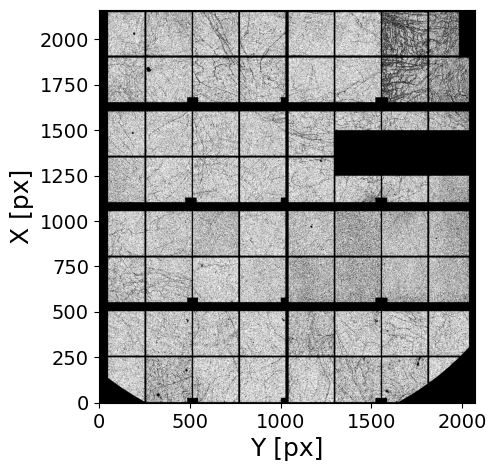

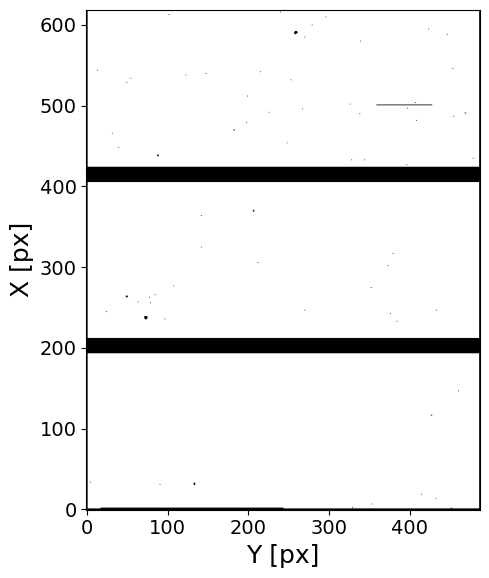

In [4]:
### MASKS
e4m_htmask_GeO2_7_30C  = np.load(MASKS_folder+'e4m_htmask-GeO2_7_30C_0003_0003' +'.npy')
e4m_htmask_GeO2_7_100C = np.load(MASKS_folder+'e4m_htmask-GeO2_7_100C_0001_0003'+'.npy')
e4m_htmask_GeO2_7_170C = np.load(MASKS_folder+'e4m_htmask-GeO2_7_170C_0001_0003'+'.npy')
e4m_htmask_GeO2_7_240C = np.load(MASKS_folder+'e4m_htmask-GeO2_7_240C_0001_0003'+'.npy')
e4m_htmask = e4m_htmask_GeO2_7_30C * e4m_htmask_GeO2_7_100C * e4m_htmask_GeO2_7_170C * e4m_htmask_GeO2_7_240C

e4m_mask = np.load(MASKS_folder+'e4m_mask'+'.npy')

plt.figure(figsize=(5, 5))
plt.imshow((e4m_mask*e4m_htmask).reshape(Nx,Ny), cmap='gray', origin='lower')
plt.xlabel('Y [px]')
plt.ylabel('X [px]')
plt.tight_layout(); plt.show()

### pilatus MASKS
pilatus_mask = np.load(MASKS_folder+'pilatus300k_mask_20240201'+'.npy').astype(bool)

plt.figure(figsize=(6, 6))
plt.imshow(~pilatus_mask, cmap='gray', origin='lower')
plt.xlabel('Y [px]')
plt.ylabel('X [px]')
plt.tight_layout(); plt.show()

### Beamstop mask

In [5]:
#######################################
sample_name = 'GeO2_7_30C'
Ndataset = 3
Nscan = 3
Nfi, Nff = 0, 1000
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, )

#############################
command = mtimescan 0.001 1 1800288
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/1 loops)
Done! (elapsed time = 0.19 s)
Concatenating vectors ...
Done! (elapsed time = 0.01 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_7_30C/GeO2_7_30C_0003/scan0003/
	 | Shape:       (1000, 4471016)
	 | Sparsity:     1.5e-04
	 | Memory usage (scipy.csr_array): 0.007 GB (np.array usage: 16.656 GB)


################################################################################
Maximum count in the whole run -> 242.0
# of pixels above Ith_high treshold ->  610960 pixels (of 4471016 => 13.66 %)
################################################################################



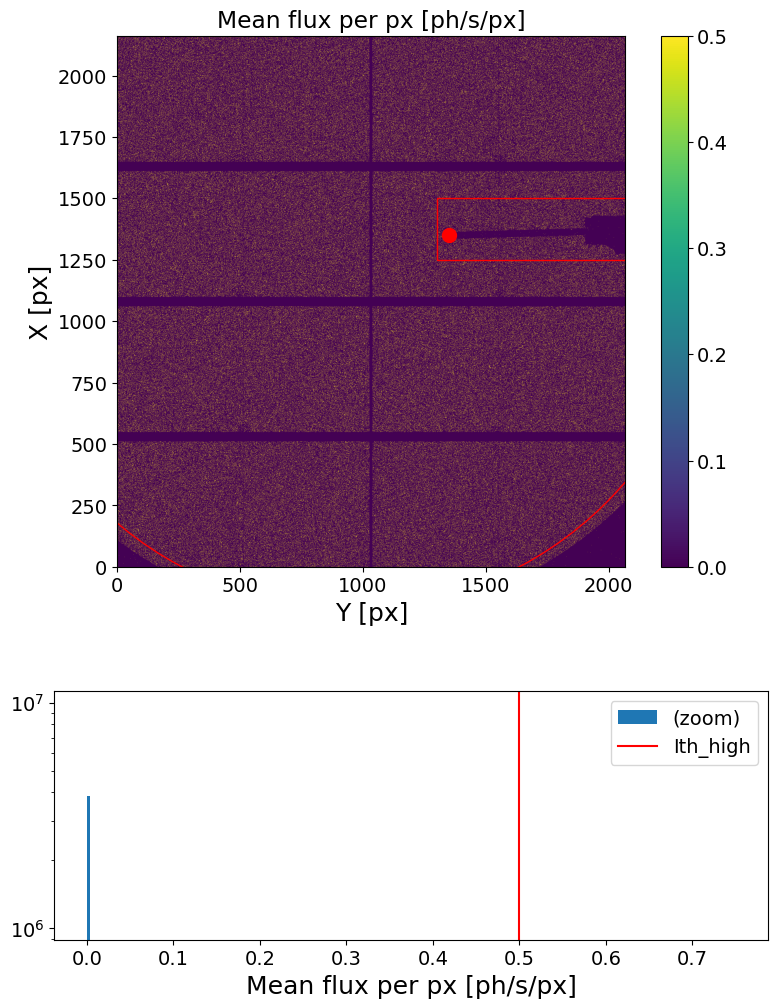

In [6]:
geom = [{'geom':'Rectangle', 'x0':1250, 'y0':1300, 'xl':250, 'yl':1950, 'inside':False},
        {'geom':'Circle', 'Cx':1300, 'Cy':950, 'r':1470, 'inside':True}, 
        ]
XPCS.gen_plots4mask(e4m_data, itime, Ith_high=.5, mask_geom=geom,)

#################################################
Masked area =  93.74594052000708 %
#################################################



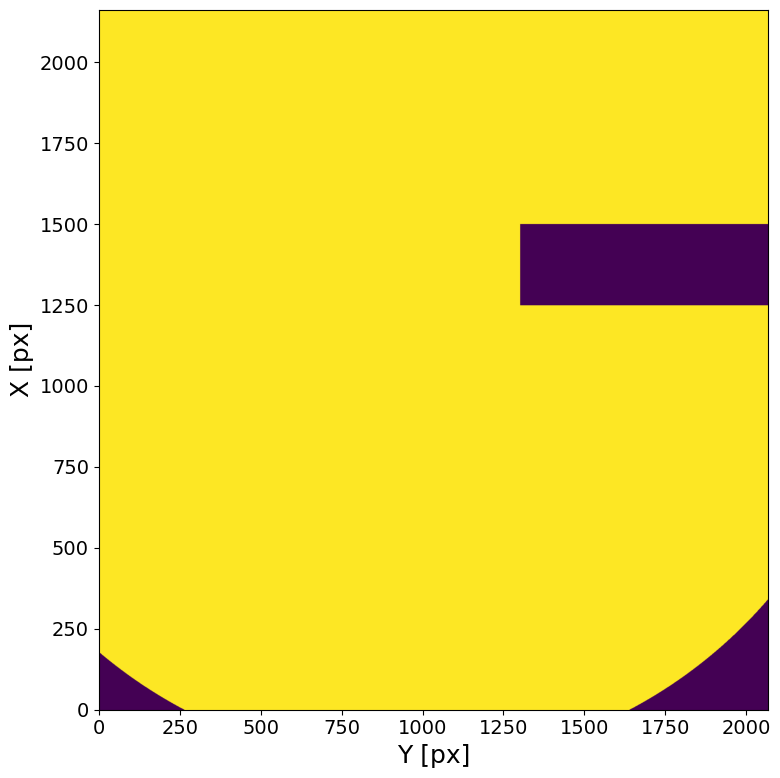

In [7]:
bs_mask = XPCS.gen_mask(mask_geom=geom)

### Q mask

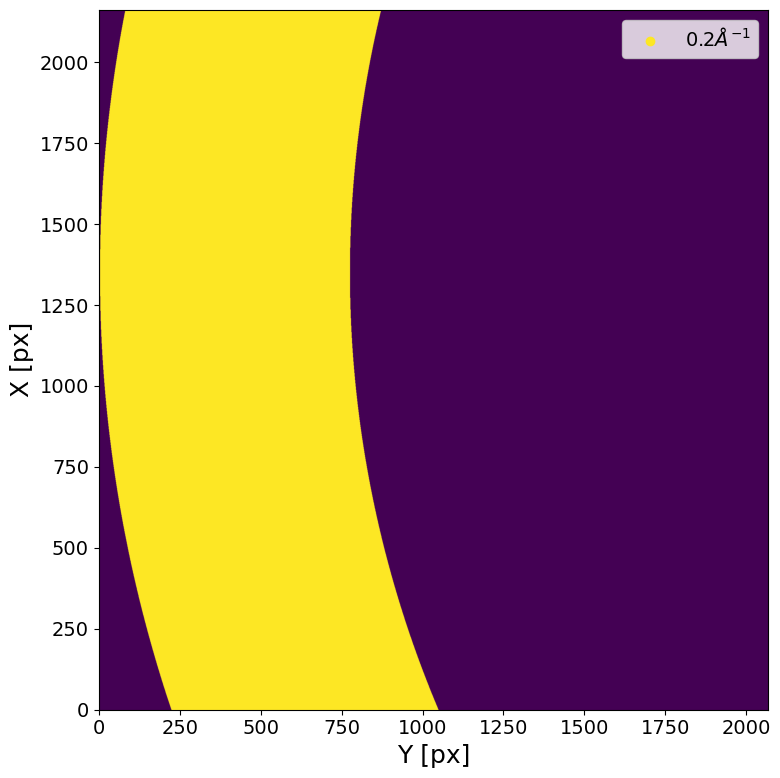

In [8]:
###################
Q_notebook = .2 # [.21, .19, .17, .15, .13]
dQ_notebook = .02 # => Q_width = 2*dQ
###################

Qmask = XPCS.gen_Qmask(Ei, theta, Q_notebook, dQ_notebook, Qmap_plot=False)

### htmask killed pixels ?

In [9]:
print(f'Percentage of kept pixel by e4m_htmask_GeO2_7_30C:  {round((bs_mask*Qmask*e4m_mask*e4m_htmask_GeO2_7_30C).sum() / (bs_mask*Qmask*e4m_mask).sum()*100,2)}%')
print(f'Percentage of kept pixel by e4m_htmask_GeO2_7_100C: {round((bs_mask*Qmask*e4m_mask*e4m_htmask_GeO2_7_100C).sum() / (bs_mask*Qmask*e4m_mask).sum()*100,2)}%')
print(f'Percentage of kept pixel by e4m_htmask_GeO2_7_170C: {round((bs_mask*Qmask*e4m_mask*e4m_htmask_GeO2_7_170C).sum() / (bs_mask*Qmask*e4m_mask).sum()*100,2)}%')
print(f'Percentage of kept pixel by e4m_htmask_GeO2_7_240C: {round((bs_mask*Qmask*e4m_mask*e4m_htmask_GeO2_7_240C).sum() / (bs_mask*Qmask*e4m_mask).sum()*100,2)}%')

print(f'Percentage of kept pixel by e4m_htmask:             {round((bs_mask*Qmask*e4m_mask*e4m_htmask).sum() / (bs_mask*Qmask*e4m_mask).sum()*100,2)}%')

Percentage of kept pixel by e4m_htmask_GeO2_7_30C:  89.0%
Percentage of kept pixel by e4m_htmask_GeO2_7_100C: 91.76%
Percentage of kept pixel by e4m_htmask_GeO2_7_170C: 87.32%
Percentage of kept pixel by e4m_htmask_GeO2_7_240C: 94.62%
Percentage of kept pixel by e4m_htmask:             74.85%


# Alligment

## XPCS scan: [Alligment] T=30C, Q=0.19, 3min@200ms (1002fm) (GeO2_6, dataset 1, scan 7)

In [10]:
#######################################
sample_name = 'GeO2_6'
Ndataset = 1
Nscan = 7
Nfi, Nff = 1, None # skip beamstop opening
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4*20)

#############################
command = mtimescan 0.2 1 1002
Ei = 9.699998837562536
itime = 0.200112
theta = 1.7500000000000004
Q = 0.15
T = 3.34 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/1 loops)


Done! (elapsed time = 8.19 s)
Concatenating vectors ...
Done! (elapsed time = 0.13 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_6/GeO2_6_0001/scan0007/
	 | Shape:       (1001, 1074960)
	 | Sparsity:     3.9e-02
	 | Memory usage (scipy.csr_array): 0.465 GB (np.array usage: 4.009 GB)
Filtering gamma ray signal (i.e. signals over treshold) ...
Done! (elapsed time = 0.19 s)
Removing gamma ray signal (set 0s) ...
Done! (elapsed time = 0.32 s)


### Flux check

################################################################################
Maximum count in the whole run -> 80.0
################################################################################



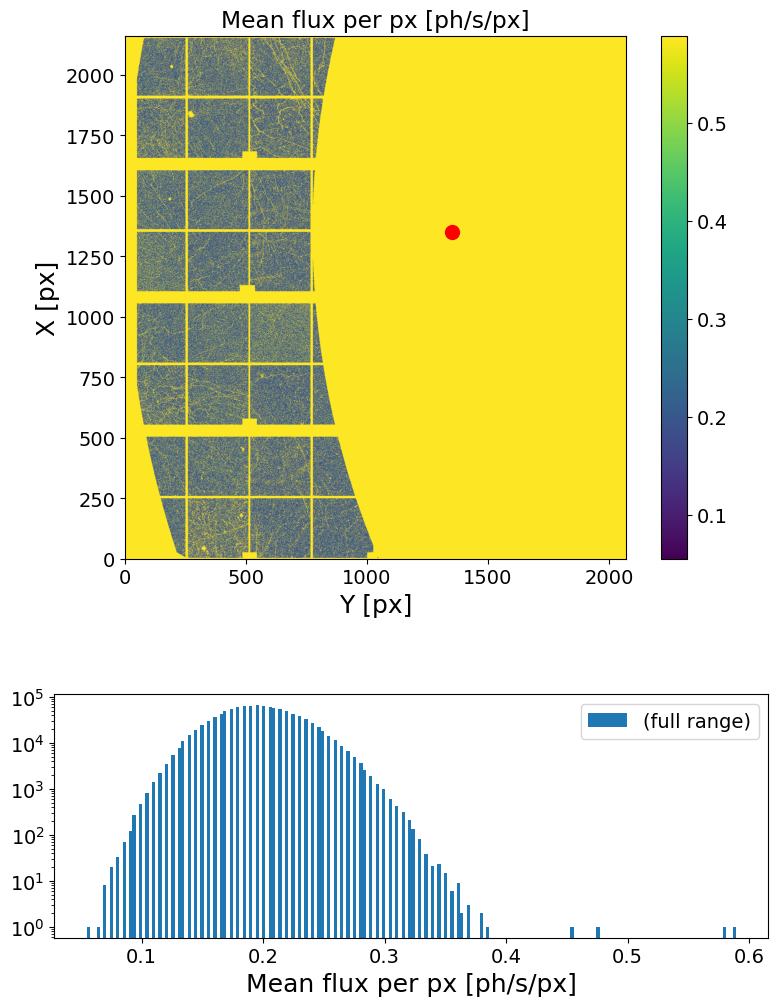

In [11]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [12]:
####################
Lbin = 1
Nstep = 1
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
#np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

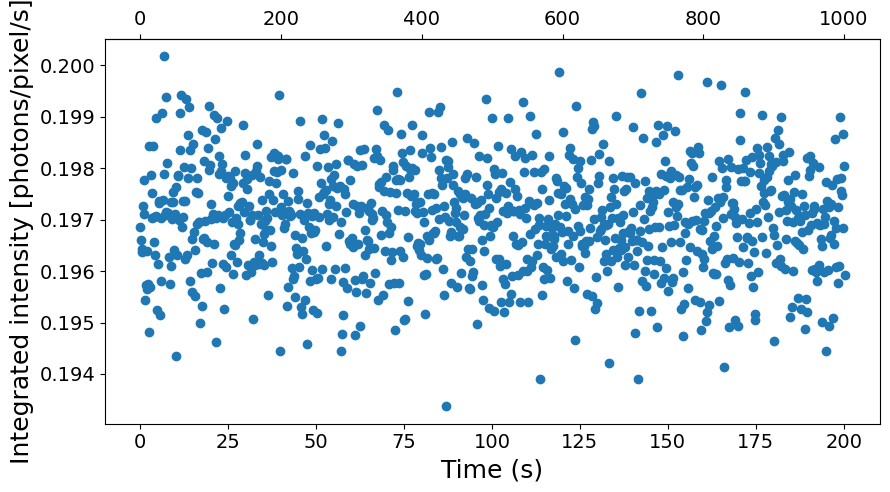

In [13]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))

## XPCS scan: [Alligment] T=30C, Q=0.19, 20min @ 200ms (6000fm) @ damaged point (GeO2_6, dataset 1, scan 8)
Trying to understend the best itime (still didn't know we can go at full spid).

In [14]:
#######################################
sample_name = 'GeO2_6'
Ndataset = 1
Nscan = 8
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4*200)

#############################
command = mtimescan 0.2 1 6000
Ei = 9.699998837562536
itime = 0.200112
theta = 1.7500000000000004
Q = 0.15
T = 20.01 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/2 loops)


	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/2 loops)
Done! (elapsed time = 33.8 s)
Concatenating vectors ...
Done! (elapsed time = 0.89 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_6/GeO2_6_0001/scan0008/
	 | Shape:       (5999, 1074960)
	 | Sparsity:     3.9e-02
	 | Memory usage (scipy.csr_array): 2.779 GB (np.array usage: 24.023 GB)
Filtering gamma ray signal (i.e. signals over treshold) ...
Done! (elapsed time = 1.03 s)
Removing gamma ray signal (set 0s) ...
Done! (elapsed time = 1.79 s)


### Flux check

################################################################################
Maximum count in the whole run -> 786.0
################################################################################



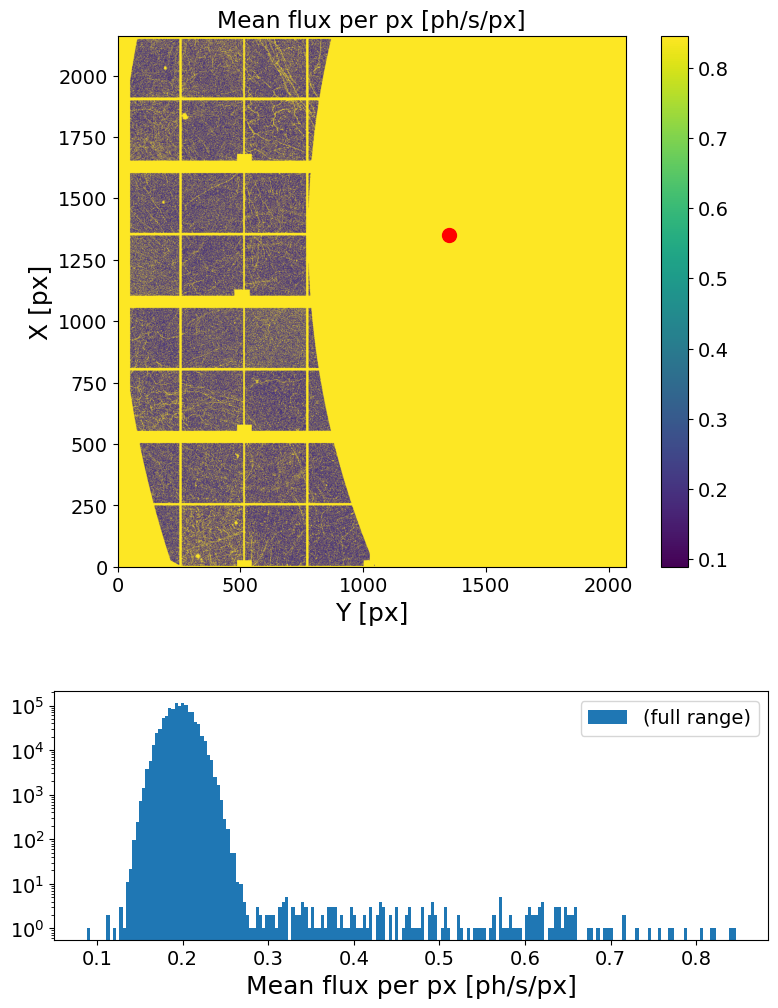

In [15]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [16]:
####################
Lbin = 10
Nstep = 10
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
#np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

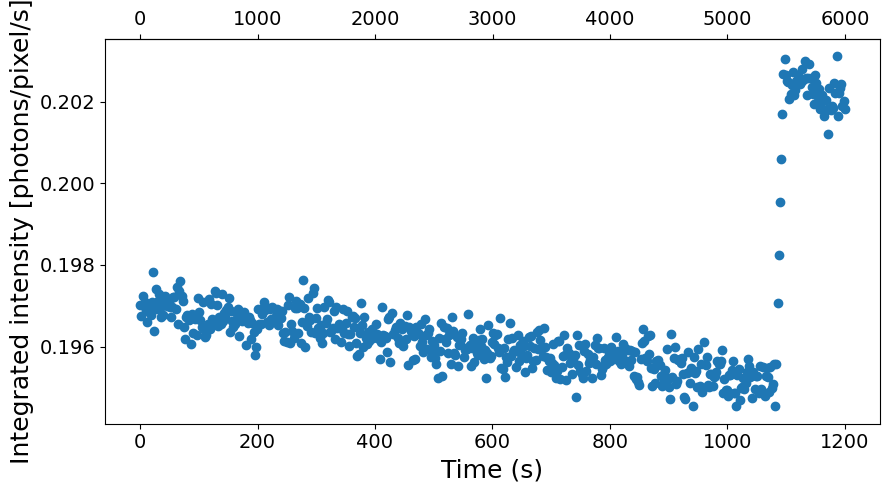

In [17]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))

### Linear correlation of damaged-vGeO2

In [18]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=5000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
#np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...


Done! (elapsed time = 0.24 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 2.16 s)
	 | 999 X 999 squared matrix
	 | memory usage (np.array @ float32) = 0.004 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 0.03 s)

Computing g2 (using cython code)...
Done! (elapsed time = 0.0 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.2,0.02,5.217292,0.220072,4.218133,0.748687,0.023822,3.181792,0.032744,0.000834,2.548081,1.001101,0.000049,0.004936,1.036631


/tmp/ipykernel_452558/4212458604.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


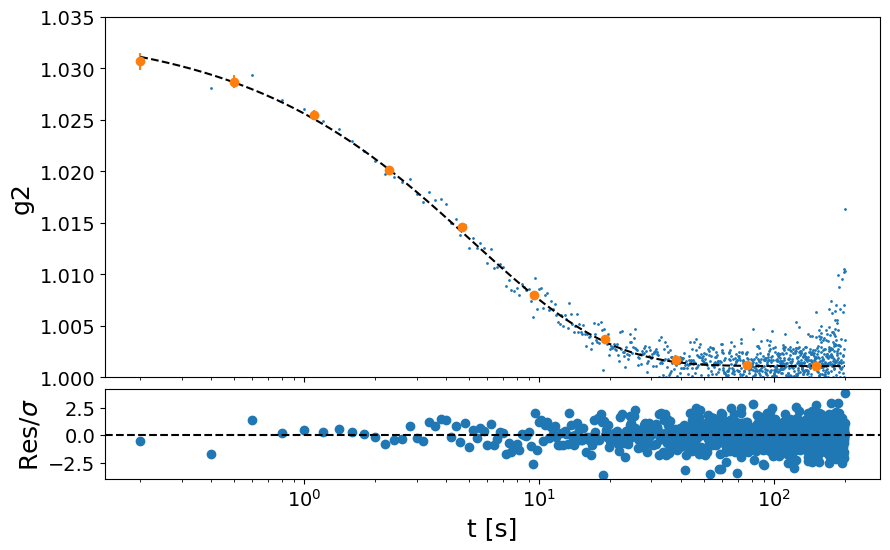

In [19]:
##################
t1_fit = 0
t2_fit = 1e100
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=False)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

# First scans @ room T

## XPCS scan: T=30 C, Q=0.19, 20min @ 20ms ON **damaged point** (GeO2_6, dataset 1, scan 9)

In [20]:
#######################################
sample_name = 'GeO2_6'
Ndataset = 1
Nscan = 9
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4*20)

#############################
command = mtimescan 0.02 1 60000
Ei = 9.699998837562536
itime = 0.020101
theta = 1.7500000000000004
Q = 0.15
T = 20.10 min
#############################

Loading sparse array ...


	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/12 loops)
Done! (elapsed time = 20.25 s)
Concatenating vectors ...
Done! (elapsed time = 1.3 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_6/GeO2_6_0001/scan0009/
	 | Shape:       (59999, 1074960)
	 | Sparsity:  

### Flux check

################################################################################
Maximum count in the whole run -> 78.0
################################################################################



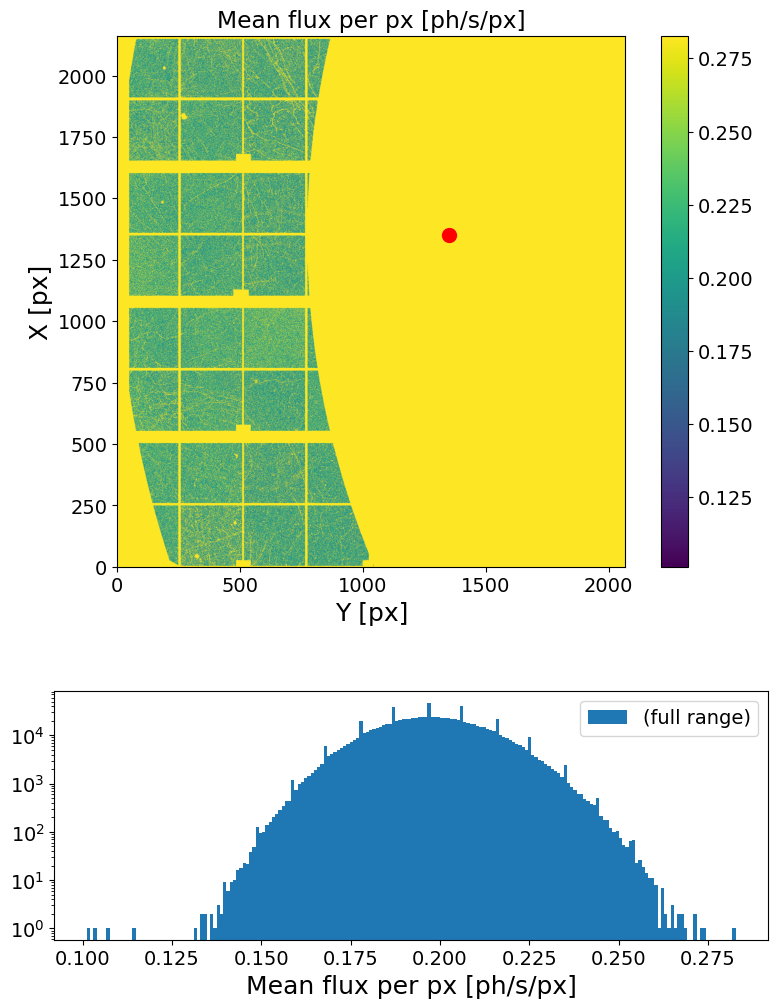

In [21]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [22]:
####################
Lbin = 10
Nstep = 10
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

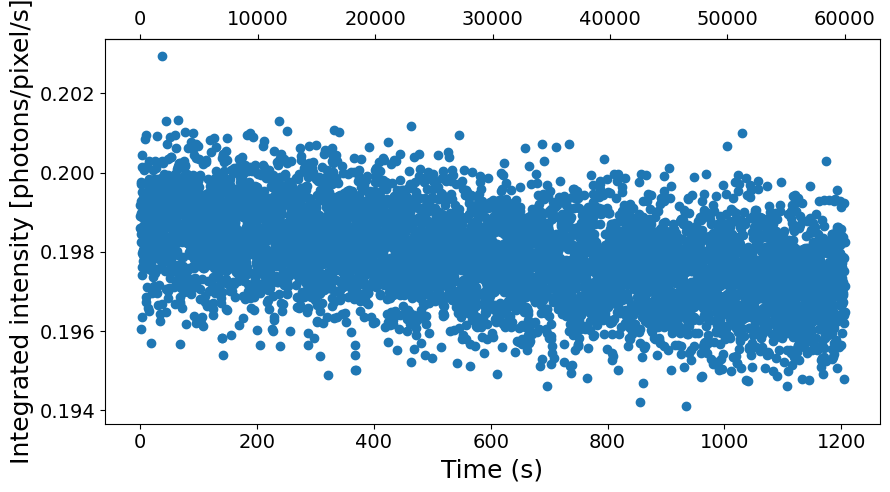

In [23]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))

### Linear correlation of damaged-vGeO2

In [24]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=None, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...
Done! (elapsed time = 0.0 s)
Computing G2t (using MKL library)...


Done! (elapsed time = 27.58 s)
	 | 59999 X 59999 squared matrix
	 | memory usage (np.array @ float32) = 13.411 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 2.3 s)

Computing g2 (using cython code)...
Done! (elapsed time = 3.55 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.2,0.02,5.157137,0.071778,1.391821,0.761857,0.008506,1.116519,0.032468,0.000273,0.841938,1.001258,0.00002,0.002001,1.021349


/tmp/ipykernel_452558/1570456126.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


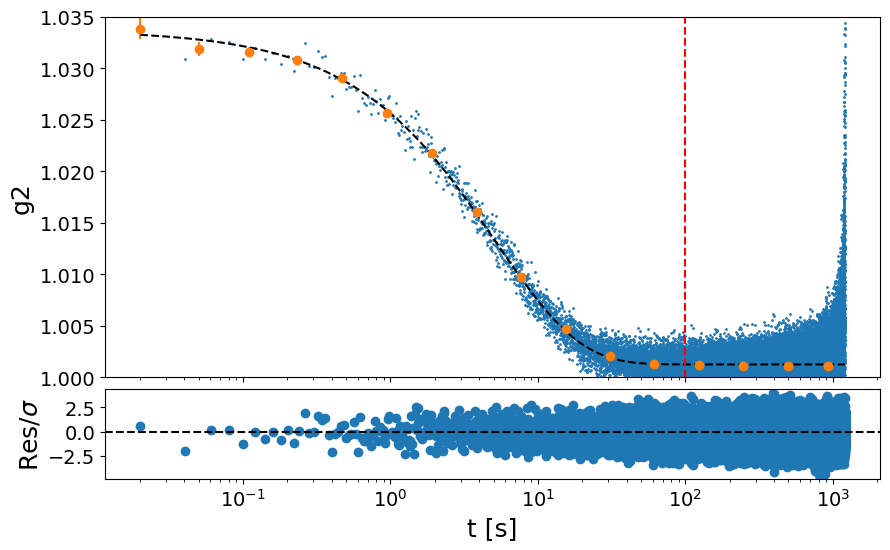

In [25]:
##################
t1_fit = 0
t2_fit = 1e2
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

## XPCS scan: [Test on fresh p] T=30C, Q=0.19, 5min @ 20ms ON **fresh point** (GeO2_6, dataset 1, scan 11)
Test for going down in itime (still didn't know we can go at full spid)...

In [26]:
#######################################
sample_name = 'GeO2_6'
Ndataset = 1
Nscan =11
Nfi, Nff = 1, None
mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4*20)

#############################
command = mtimescan 0.02 1 15000
Ei = 9.699998837562536
itime = 0.020101
theta = 1.7500000000000004
Q = 0.15
T = 5.03 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/3 loops)


	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/3 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/3 loops)
Done! (elapsed time = 27.66 s)
Concatenating vectors ...
Done! (elapsed time = 0.2 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_6/GeO2_6_0001/scan0011/
	 | Shape:       (14999, 1074960)
	 | Sparsity:     4.0e-03
	 | Memory usage (scipy.csr_array): 0.729 GB (np.array usage: 60.064 GB)
Filtering gamma ray signal (i.e. signals over treshold) ...
Done! (elapsed time = 0.29 s)
Removing gamma ray signal (set 0s) ...
Done! (elapsed time = 0.46 s)


### Flux check

In [27]:
#XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [28]:
####################
Lbin = 10
Nstep = 10
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

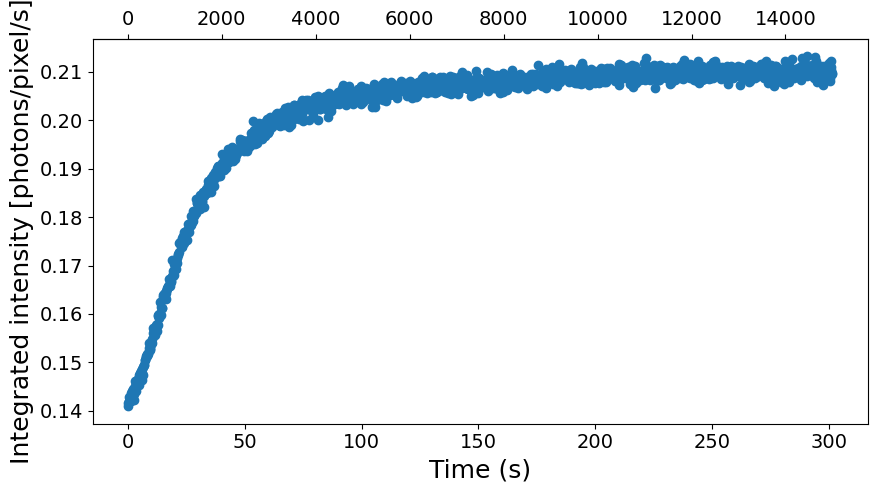

In [29]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))

# XPCS scan: T=30C, Q=0.19, 75min @ 20ms ON damaged point (GeO2_6, dataset 1, scan 12)
Start the Temperature ramp!

In [30]:
#######################################
sample_name = 'GeO2_6'
Ndataset = 1
Nscan =12
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4*20)

#############################
command = mtimescan 0.02 1 220000
Ei = 9.699998837562536
itime = 0.0201
theta = 1.7500000000000004
Q = 0.15
T = 73.70 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00012.h5 (13/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00013.h5 (14/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00014.h5 (15/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00015.h5 (16/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00016.h5 (17/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00017.h5 (18/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00018.h5 (19/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00019.h5 (20

	 -> loading file eiger4m_v2_sparse_frame_0_00020.h5 (21/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00021.h5 (22/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00022.h5 (23/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00023.h5 (24/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00024.h5 (25/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00025.h5 (26/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00026.h5 (27/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00027.h5 (28/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00028.h5 (29/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00029.h5 (30/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00030.h5 (31/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00031.h5 (32/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00032.h5 (33/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00033.h5 (34/44 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00034.h5 (35/44 lo

KeyboardInterrupt: 

### Flux check

################################################################################
Maximum count in the whole run -> 3.0
################################################################################



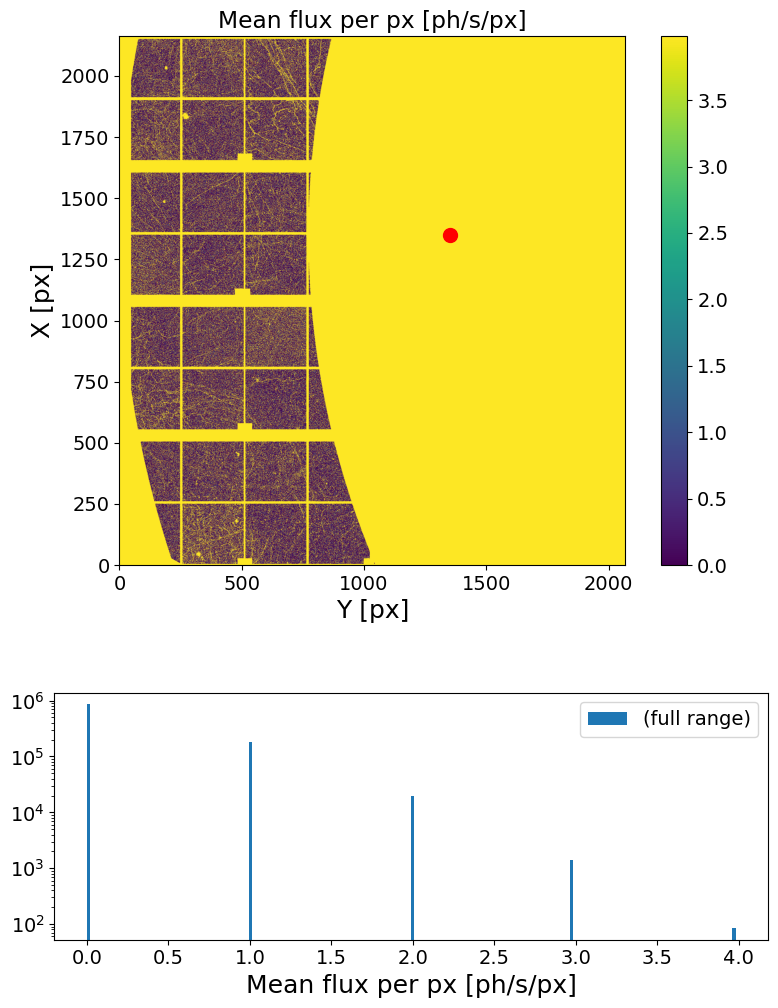

In [ ]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=50, load_mask=load_mask)

### Intensity analysis

In [ ]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

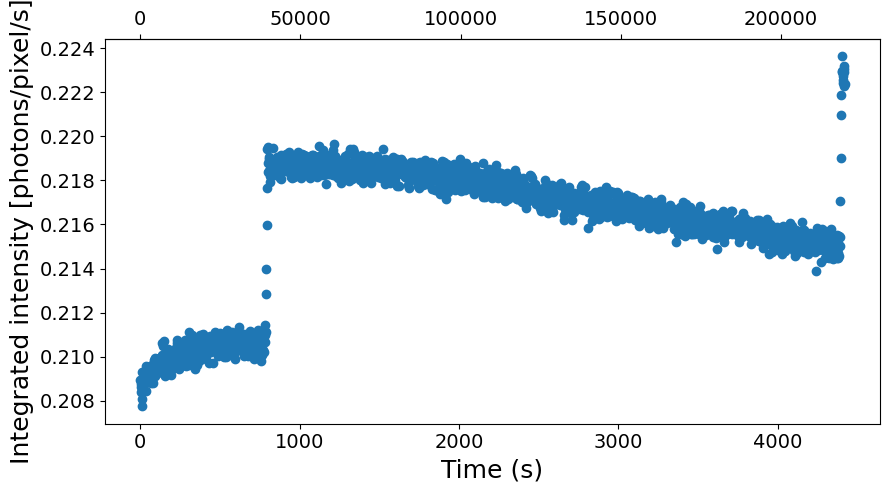

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [ ]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=100000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...


Done! (elapsed time = 8.65 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 73.81 s)
	 | 119999 X 119999 squared matrix
	 | memory usage (np.array @ float32) = 53.643 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 9.49 s)

Computing g2 (using cython code)...
Done! (elapsed time = 12.25 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.2,0.02,5.19125,0.051588,0.993741,0.724357,0.004891,0.675165,0.030866,0.000172,0.555929,1.001131,0.000003,0.000268,1.002462


/tmp/ipykernel_242518/1096979051.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


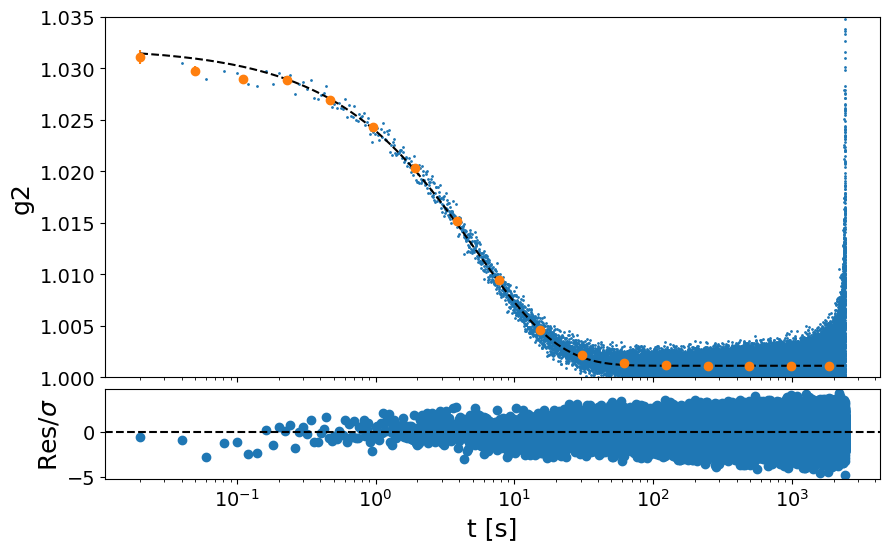

In [ ]:
##################
t1_fit = None
t2_fit = 1e2
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

# XPCS scan: T=100C, Q=0.19, 20min @ 20ms (GeO2_6, dataset 1, scan 3)

In [ ]:
#######################################
sample_name = 'GeO2_6_100C'
Ndataset = 1
Nscan =3
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4*20)

#############################
command = mtimescan 0.02 1 60000
Ei = 9.699998837562536
itime = 0.020101
theta = 1.7500000000000004
Q = 0.15
T = 20.10 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/12 loo

### Flux check

################################################################################
Maximum count in the whole run -> 80.0
################################################################################



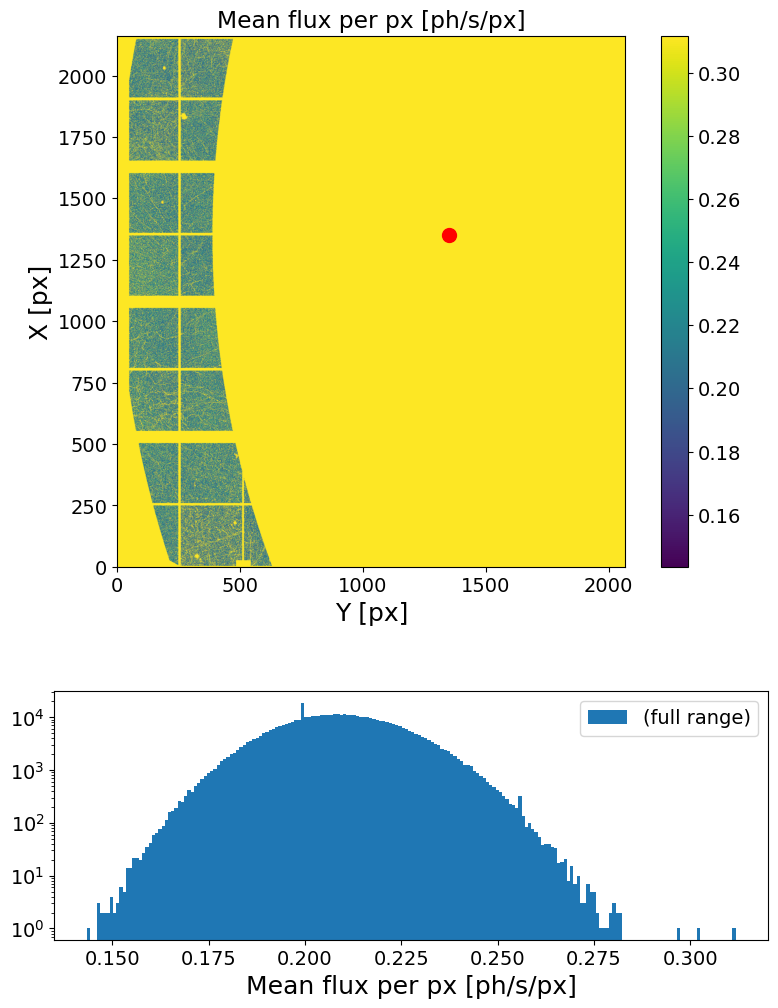

In [ ]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [ ]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

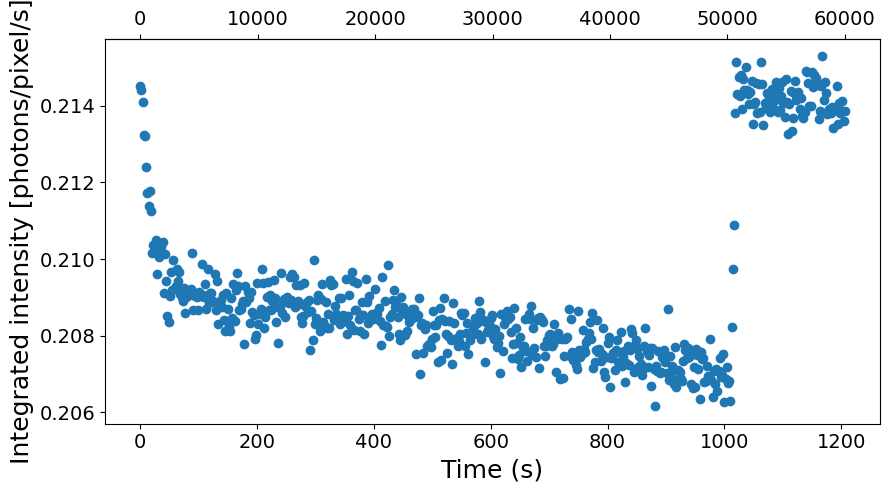

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [ ]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=10000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...
Done! (elapsed time = 1.06 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 9.06 s)
	 | 49999 X 49999 squared matrix
	 | memory usage (np.array @ float32) = 9.313 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 1.08 s)

Computing g2 (using cython code)...
Done! (elapsed time = 2.02 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,4.799046,0.121689,2.5357,0.723988,0.012634,1.745097,0.028887,0.000412,1.425144,1.001177,0.000012,0.001152,0.992445


/tmp/ipykernel_127908/2695201314.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


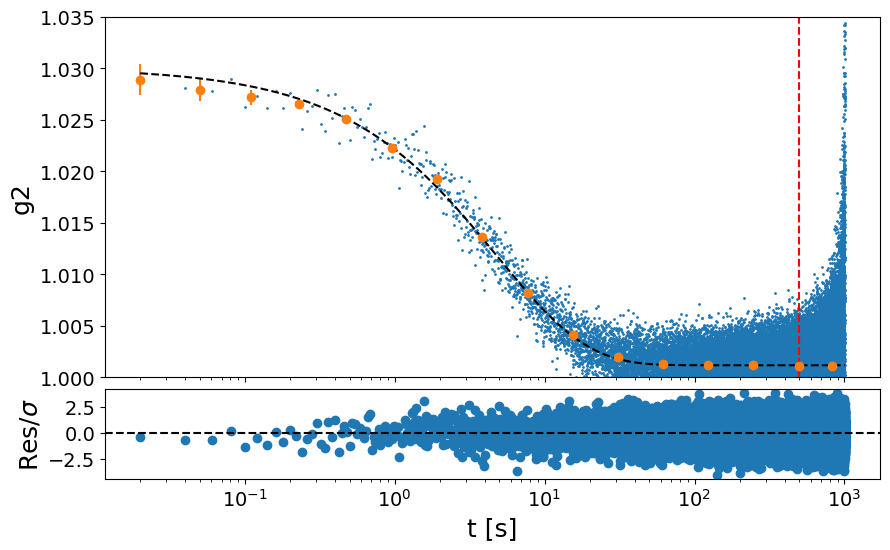

In [ ]:
##################
t1_fit = None
t2_fit = 1e2
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

# XPCS scan: T=170C, Q=0.19, 20min @ 20ms (GeO2_6, dataset 1, scan 1) 

In [ ]:
#######################################
sample_name = 'GeO2_6_170C'
Ndataset = 1
Nscan = 1
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4*20)

#############################
command = mtimescan 0.02 1 60000
Ei = 9.699998837562536
itime = 0.020101
theta = 1.7500000000000004
Q = 0.15
T = 20.10 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/12 loo

### Flux check

################################################################################
Maximum count in the whole run -> 80.0
################################################################################



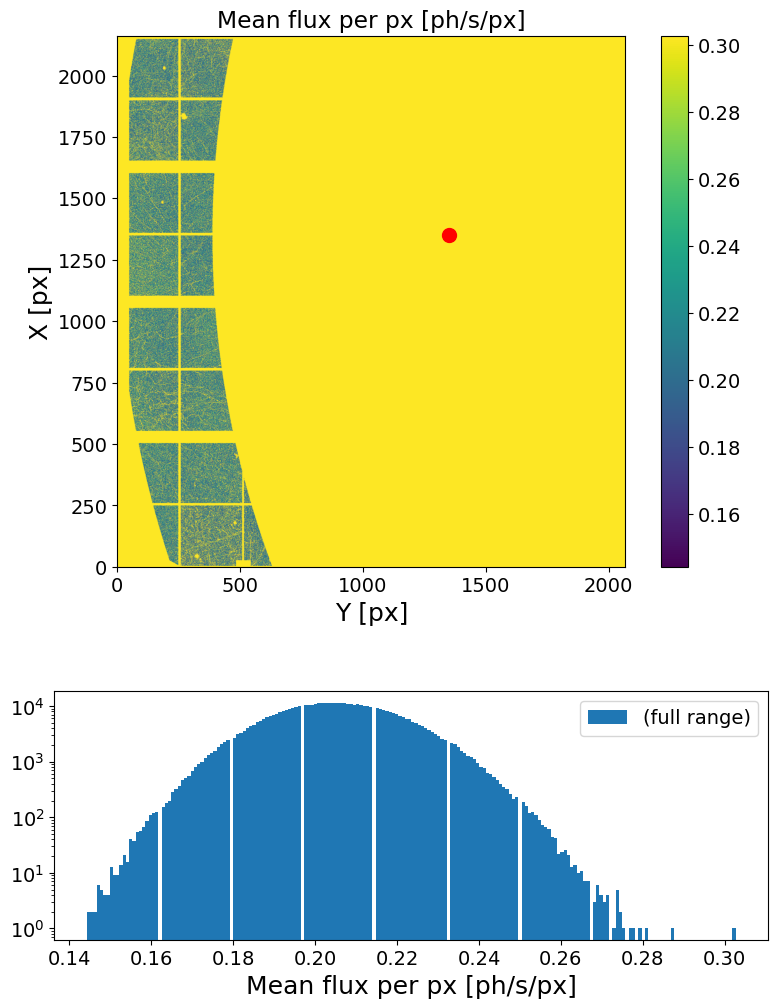

In [ ]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [ ]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

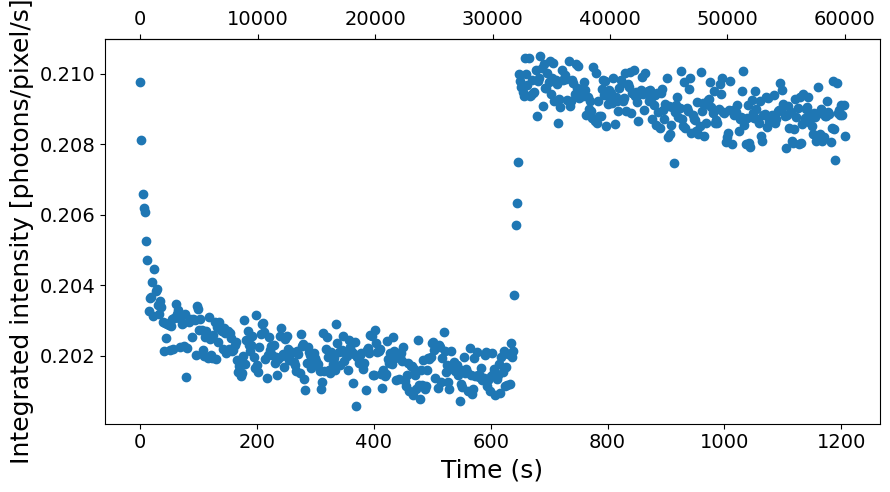

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [ ]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=10000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...


Done! (elapsed time = 1.17 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 9.05 s)
	 | 49999 X 49999 squared matrix
	 | memory usage (np.array @ float32) = 9.313 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 1.12 s)

Computing g2 (using cython code)...
Done! (elapsed time = 2.68 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,4.275085,0.118306,2.767341,0.746763,0.01485,1.988619,0.027197,0.000432,1.587016,1.00118,0.000012,0.001149,0.986992


/tmp/ipykernel_127908/2695201314.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


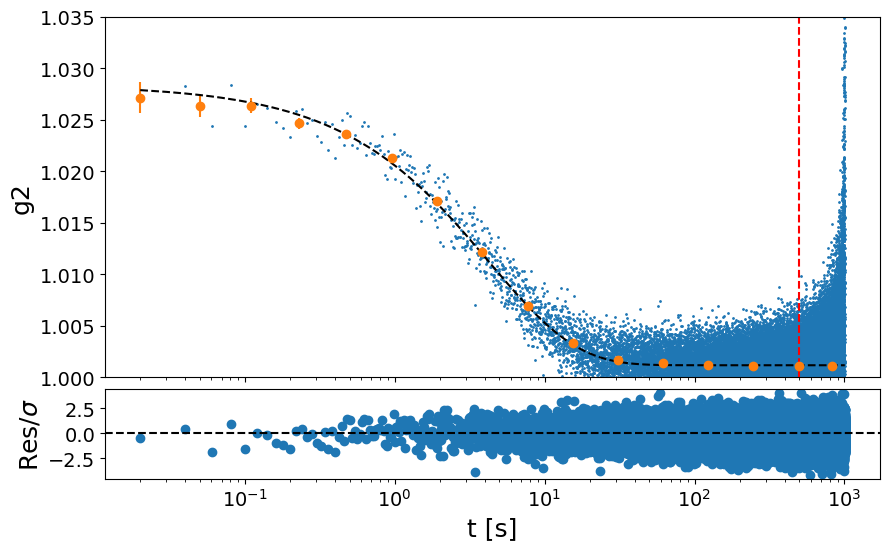

In [ ]:
##################
t1_fit = None
t2_fit = 1e2
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

# XPCS scan: T=240C , Q=0.19, 20min @ 20ms (GeO2_6, dataset 1, scan 1)

In [ ]:
#######################################
sample_name = 'GeO2_6_240C'
Ndataset = 1
Nscan = 3
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4*20)

#############################
command = mtimescan 0.02 1 60000
Ei = 9.699998837562536
itime = 0.020101
theta = 1.7500000000000004
Q = 0.15
T = 20.10 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/12 loo

### Flux check

################################################################################
Maximum count in the whole run -> 78.0
################################################################################



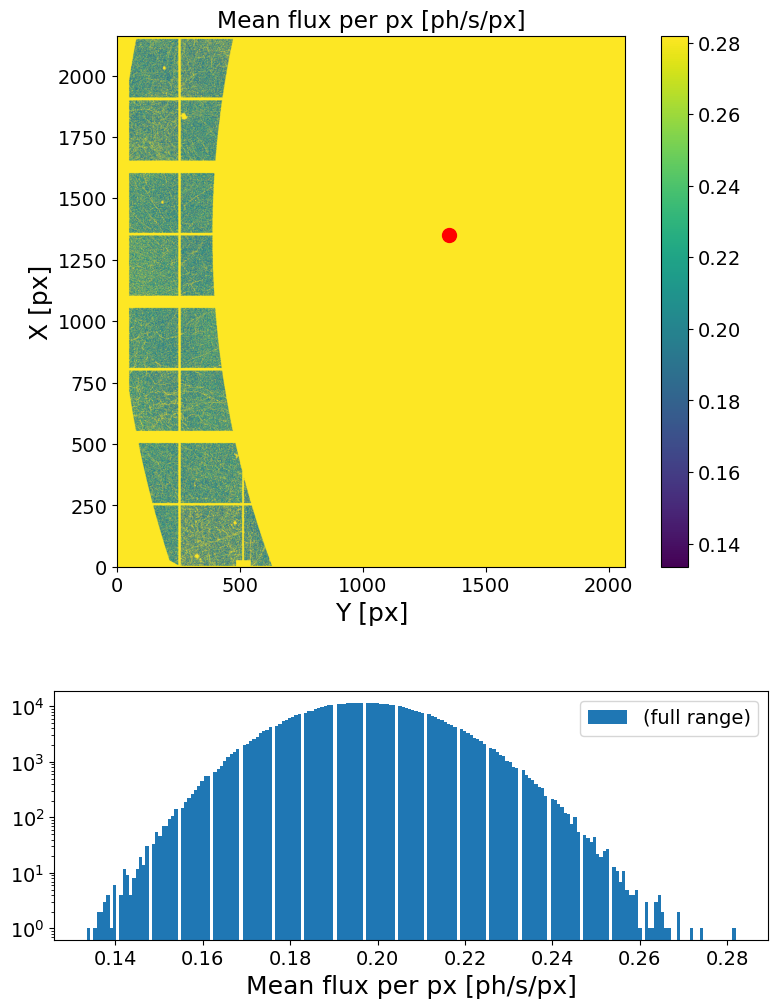

In [ ]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [ ]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

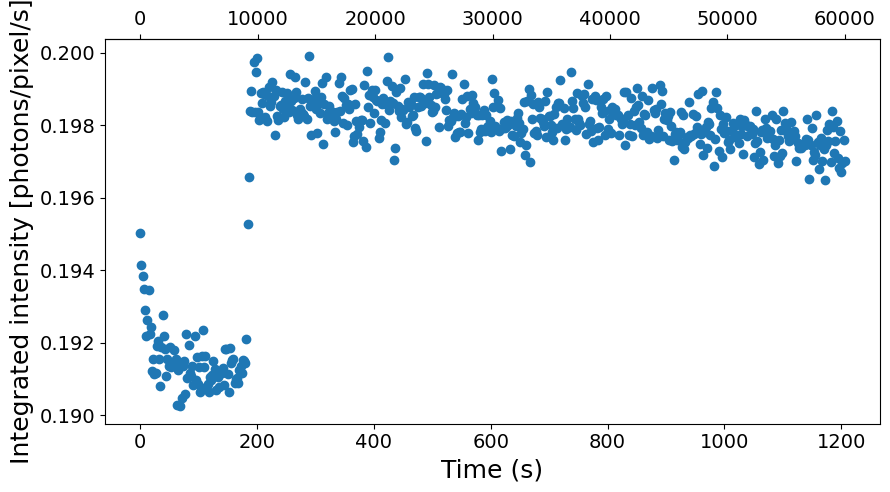

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [ ]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=10000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...


Done! (elapsed time = 1.12 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 8.61 s)
	 | 49999 X 49999 squared matrix
	 | memory usage (np.array @ float32) = 9.313 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 1.08 s)

Computing g2 (using cython code)...
Done! (elapsed time = 2.78 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,3.696431,0.120802,3.268058,0.73944,0.017975,2.430833,0.026652,0.000509,1.908012,1.001346,0.000029,0.002871,1.011485


/tmp/ipykernel_127908/3862425413.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


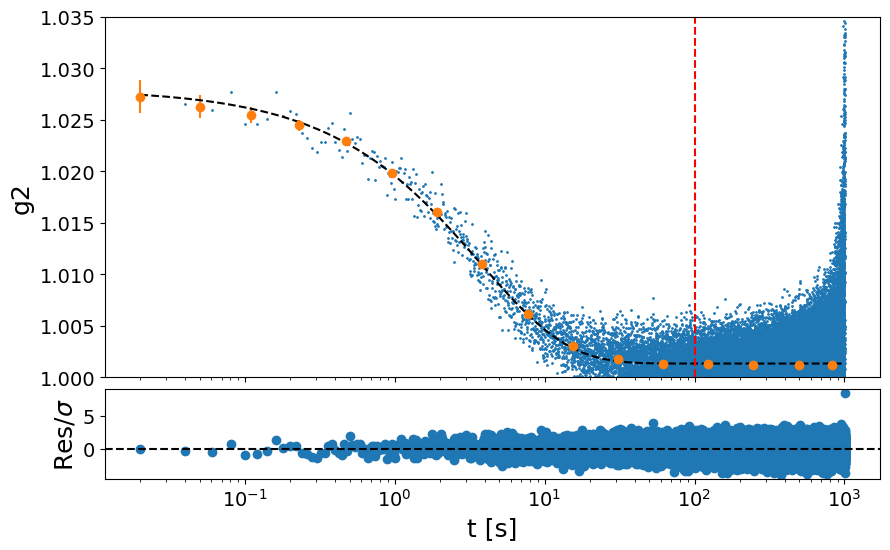

In [ ]:
##################
t1_fit = None
t2_fit = 1e2
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

# XPCS scan: T=310C, Q=0.19, 20min @ 20ms (GeO2_6, dataset 1, scan 1) 

In [ ]:
#######################################
sample_name = 'GeO2_6_310C'
Ndataset = 1
Nscan = 3
Nfi, Nff = None, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4*20)

#############################
command = mtimescan 0.02 1 60000
Ei = 9.699998837562536
itime = 0.020101
theta = 1.7500000000000004
Q = 0.15
T = 20.10 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/12 loo

Done! (elapsed time = 8.77 s)
Concatenating vectors ...
Done! (elapsed time = 0.59 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_6_310C/GeO2_6_310C_0001/scan0003/
	 | Shape:       (60000, 523950)
	 | Sparsity:     3.8e-03
	 | Memory usage (scipy.csr_array): 1.347 GB (np.array usage: 117.112 GB)
Filtering gamma ray signal (i.e. signals over treshold) ...
Done! (elapsed time = 0.71 s)
Removing gamma ray signal (set 0s) ...
Done! (elapsed time = 1.24 s)


### Flux check

################################################################################
Maximum count in the whole run -> 78.0
################################################################################



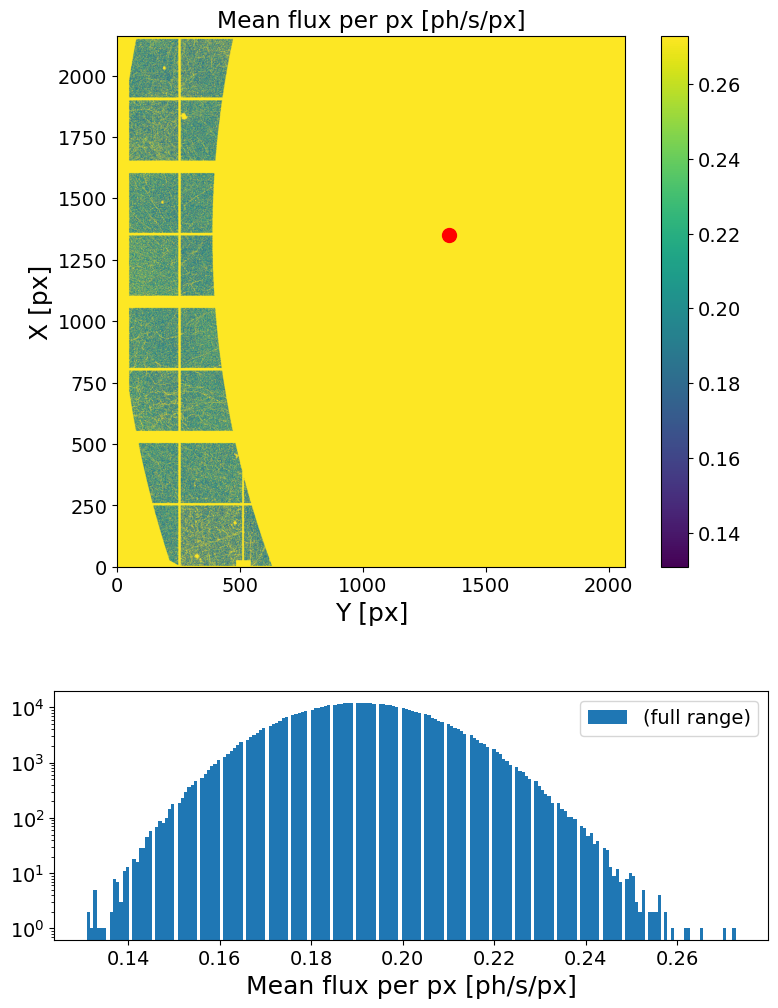

In [ ]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [ ]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

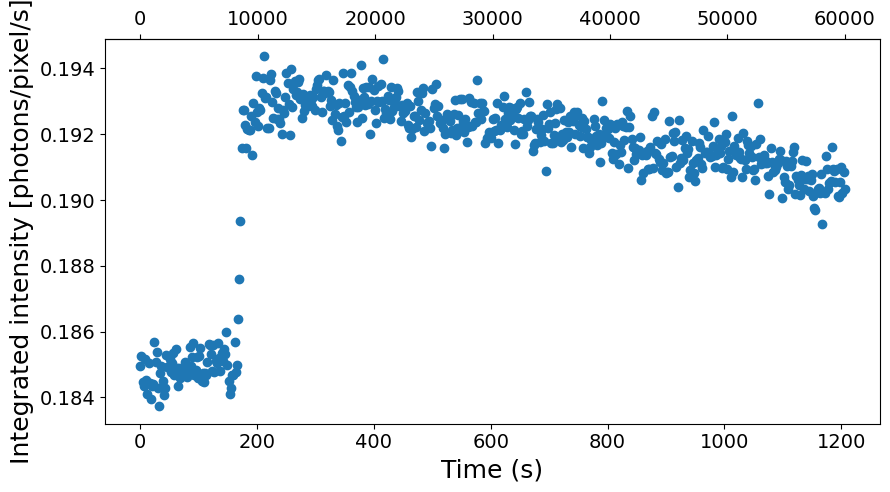

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Contrast (by Harrowell method)

In [ ]:
#################
Nf2bin = 10
#################

pat_tp = bin_data(e4m_data, Nfi=None, Nff=None, Lbin=Nf2bin)
pat_t = pat_tp.sum(axis=1)/pat_tp.shape[1]

Loading frames ...
Done! (elapsed time = 0.0 s)
Binning frames (Lbin = 10, using MKL library) ...


Done! (elapsed time = 1.32 s)
	 | 6000 frames X 523950 pixels
	 | sparsity = 3.77e-02
	 | memory usage (sparse.csr_array @ float32) = 1.323 GB


R2 mean = 49.8328, std = 0.5248466684867293


Text(0, 0.5, 'Density')

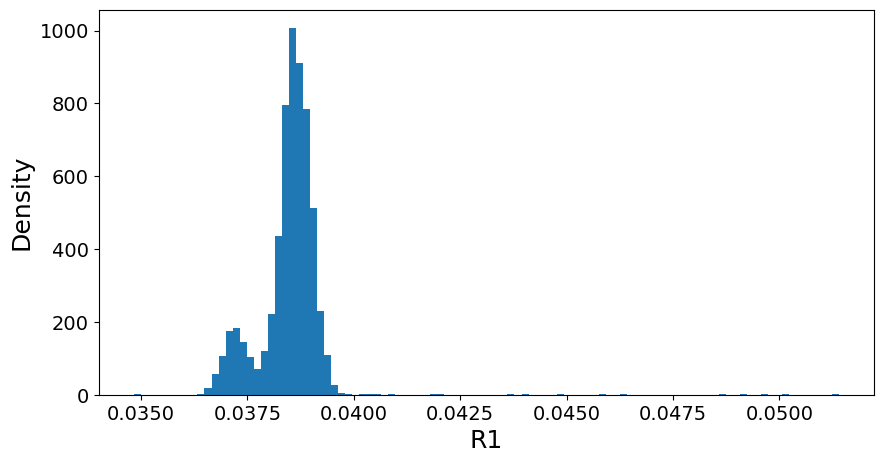

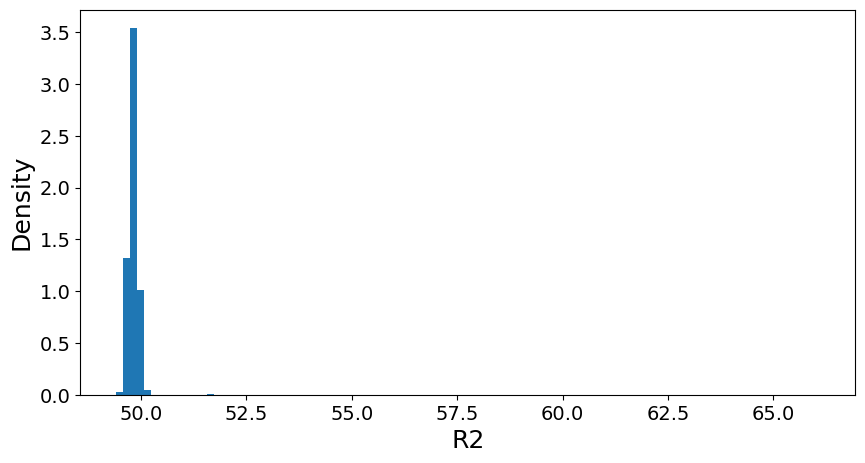

In [ ]:
R1 = (pat_tp**2).sum(axis=1)/pat_tp.shape[1] - pat_t**2
R2 = R1/pat_t/itime

print(f'R2 mean = {np.mean(R2):.4f}, std = {np.std(R2)}')

# R1 distibution
plt.figure(figsize=(10,5))
plt.hist(R1, bins=100, density=True, label='R1 distribution')
plt.xlabel('R1')
plt.ylabel('Density')

# R2 distibution
plt.figure(figsize=(10,5))
plt.hist(R2, bins=100, density=True, label='R2 distribution')
plt.xlabel('R2')
plt.ylabel('Density')

### Linear correlation of damaged-vGeO2

In [ ]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=15000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...
Done! (elapsed time = 0.95 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 7.26 s)
	 | 45000 X 45000 squared matrix
	 | memory usage (np.array @ float32) = 7.544 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 0.89 s)

Computing g2 (using cython code)...
Done! (elapsed time = 1.57 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,3.022414,0.122904,4.066421,0.724542,0.02012,2.776881,0.026353,0.000602,2.283056,1.00119,0.000013,0.001321,1.00521


/tmp/ipykernel_127908/2695201314.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


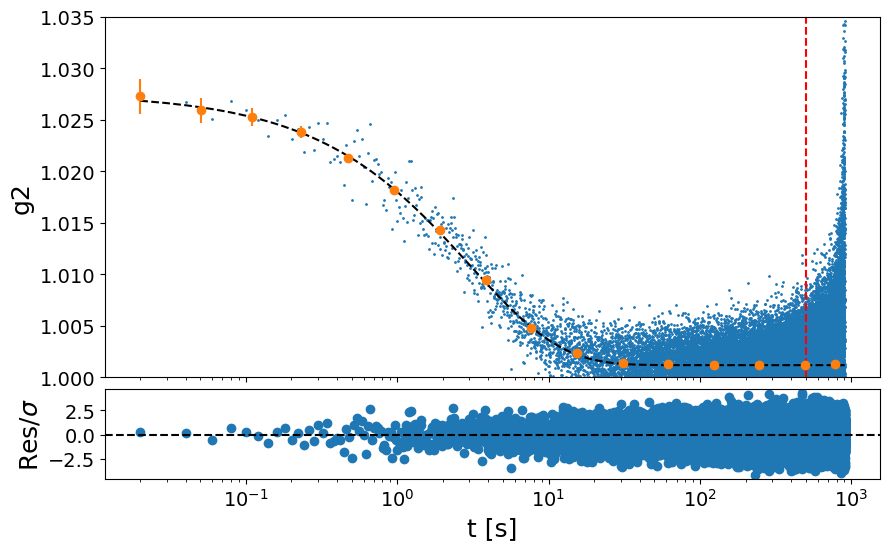

In [ ]:
##################
t1_fit = None
t2_fit = 1e2
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

#  XPCS scan: T=380C, Q=0.19, 20min@20ms (GeO2_6, dataset 1, scan 1)

In [ ]:
#######################################
sample_name = 'GeO2_6_380C'
Ndataset = 1
Nscan = 1
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4*20)

#############################
command = mtimescan 0.02 1 60000
Ei = 9.699998837562536
itime = 0.020101
theta = 1.7500000000000004
Q = 0.15
T = 20.10 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/12 loo

### Flux check

################################################################################
Maximum count in the whole run -> 79.0
################################################################################



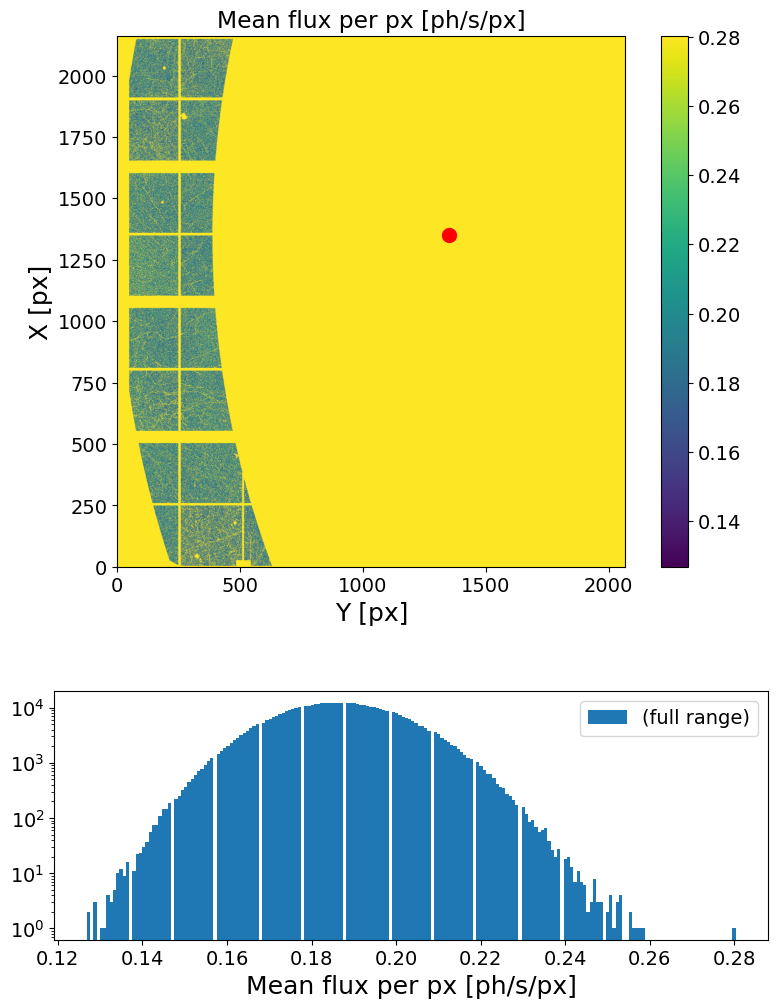

In [ ]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [ ]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

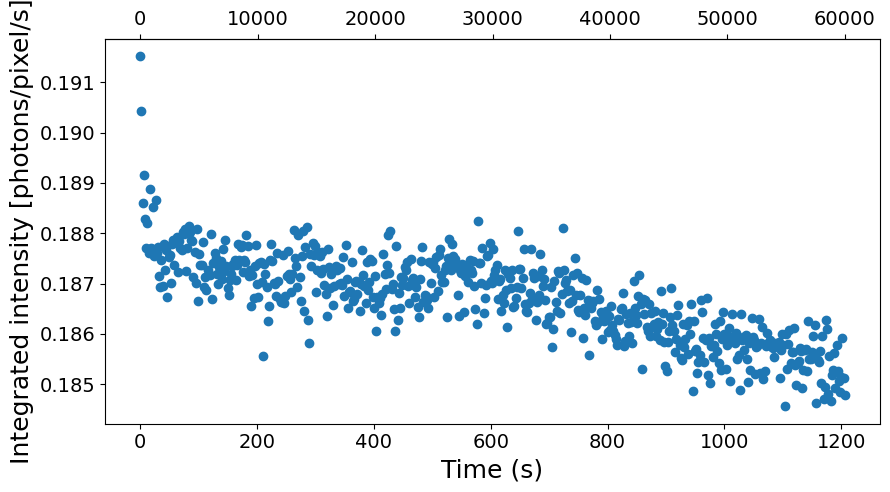

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [ ]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=15000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...


Done! (elapsed time = 0.94 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 7.03 s)
	 | 44999 X 44999 squared matrix
	 | memory usage (np.array @ float32) = 7.543 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 0.97 s)

Computing g2 (using cython code)...
Done! (elapsed time = 1.59 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,2.101633,0.117526,5.592139,0.697317,0.024991,3.583895,0.025145,0.000769,3.058256,1.001181,0.000013,0.001345,1.003734


/tmp/ipykernel_127908/2695201314.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


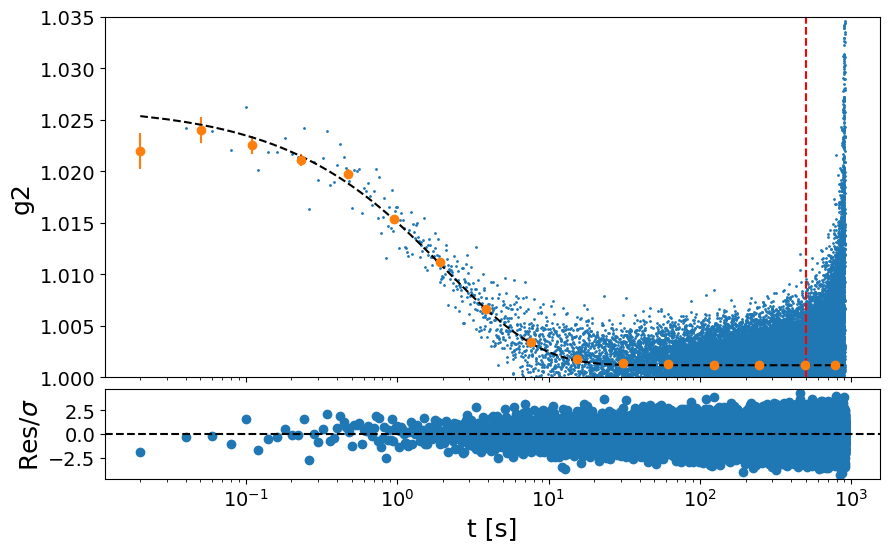

In [ ]:
##################
t1_fit = None
t2_fit = 1e2
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

#  XPCS scan:T=450 C, Q=0.19, 20min @ 20ms (60000fm) (GeO2_6, dataset 1, scan 1)

In [ ]:
#######################################
sample_name = 'GeO2_6_450C'
Ndataset = 1
Nscan = 3
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4*20)

NameError: name 'e4m_mask' is not defined

### Flux check

################################################################################
Maximum count in the whole run -> 76.0
################################################################################



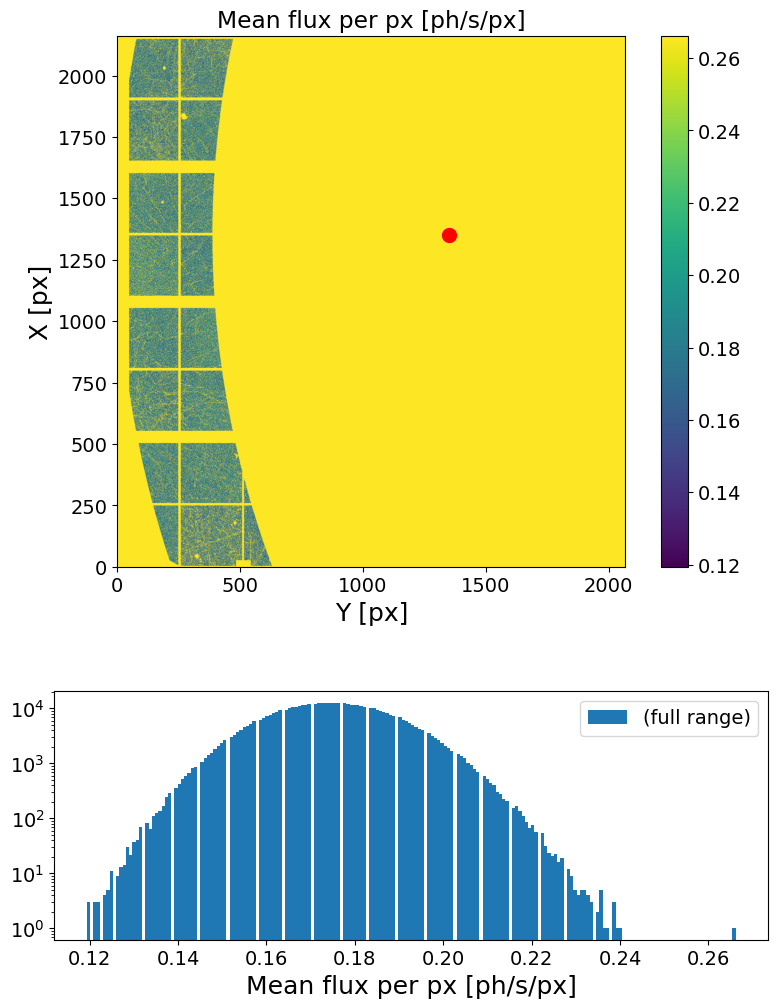

In [ ]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [ ]:
####################
Lbin = 10
Nstep = 10
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

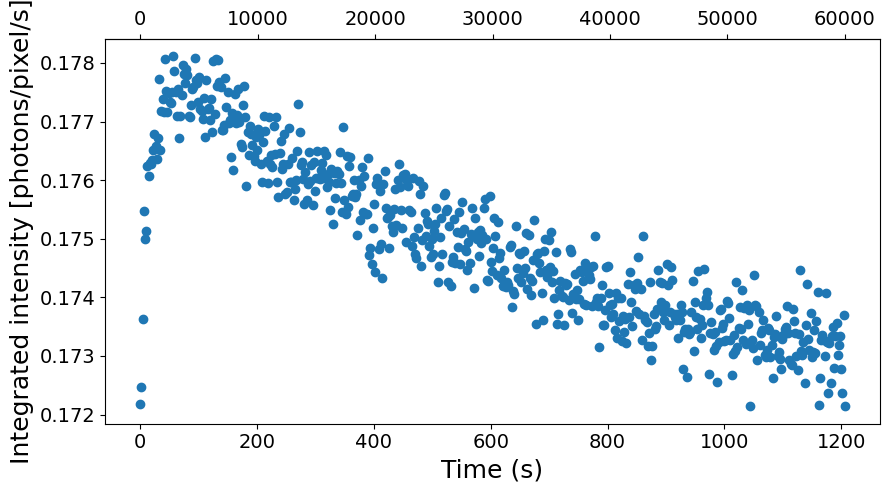

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [ ]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=15000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...


Done! (elapsed time = 0.64 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 6.73 s)
	 | 44999 X 44999 squared matrix
	 | memory usage (np.array @ float32) = 7.543 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 1.11 s)

Computing g2 (using cython code)...
Done! (elapsed time = 2.1 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,1.645947,0.128401,7.801045,0.624971,0.027241,4.358714,0.025952,0.001041,4.011405,1.001261,0.000032,0.003207,1.007506


/tmp/ipykernel_127908/3862425413.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


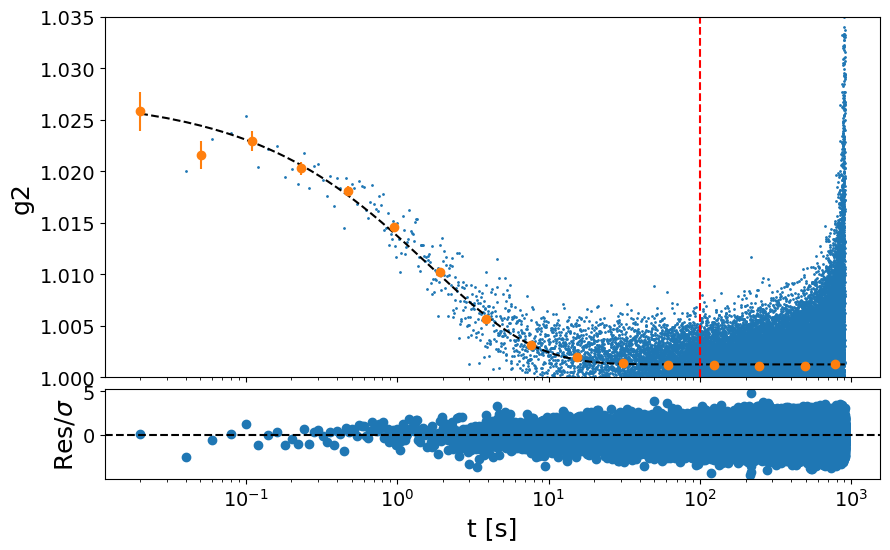

In [ ]:
##################
t1_fit = None
t2_fit = 1e2
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

#  XPCS scan: T=520C, Q=0.19, 20min @ 20ms (60000fm) (GeO2_6, dataset 1, scan 1) 

In [ ]:
#######################################
sample_name = 'GeO2_6_520C'
Ndataset = 1
Nscan = 1
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4*20)

#############################
command = mtimescan 0.02 1 60000
Ei = 9.699998837562536
itime = 0.020101
theta = 1.7500000000000004
Q = 0.15
T = 20.10 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/12 loo

### Flux check

################################################################################
Maximum count in the whole run -> 80.0
################################################################################



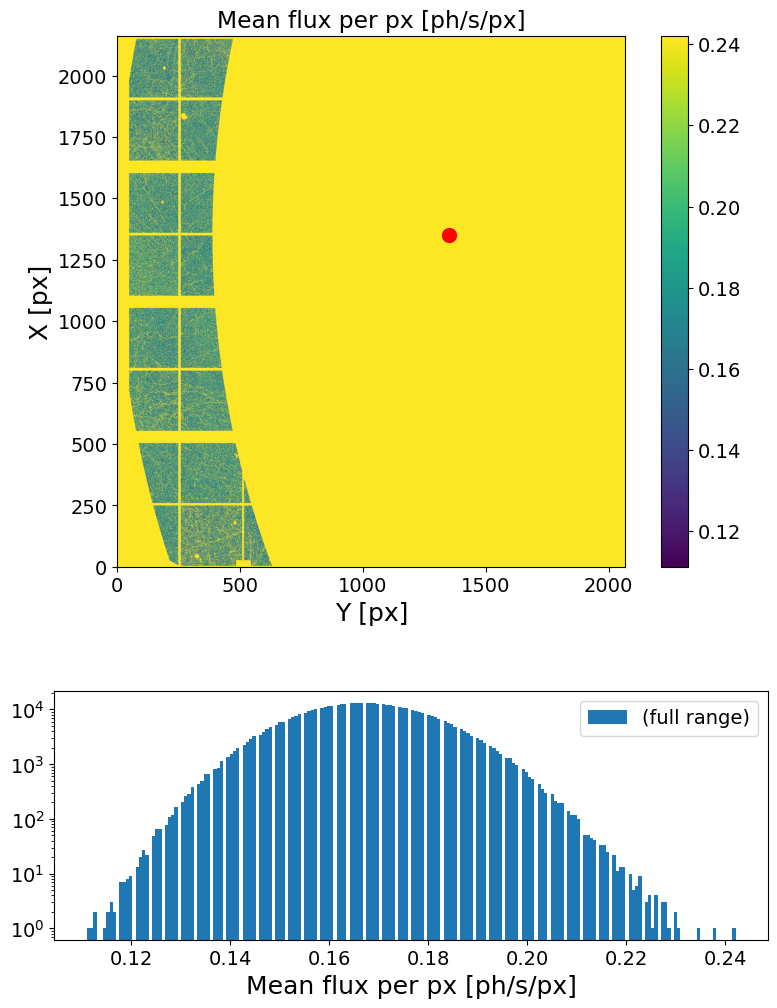

In [ ]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [ ]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

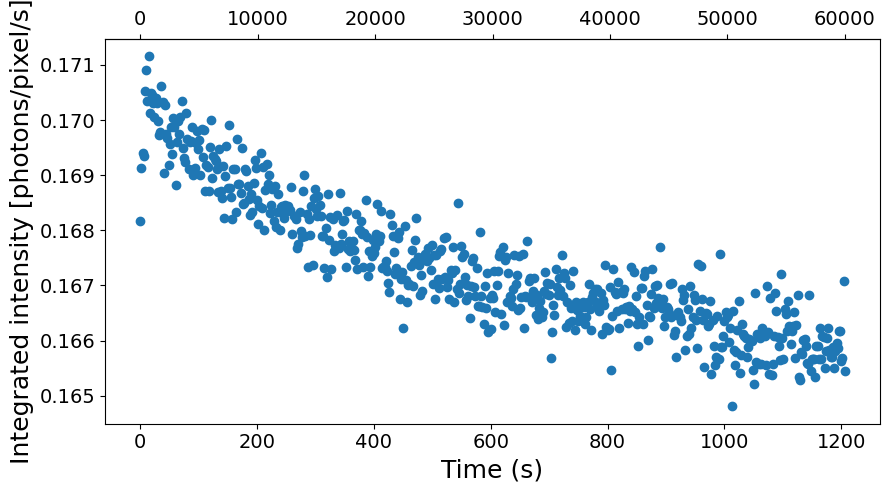

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [ ]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=15000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...


Done! (elapsed time = 0.78 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 6.24 s)
	 | 44999 X 44999 squared matrix
	 | memory usage (np.array @ float32) = 7.543 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 1.01 s)

Computing g2 (using cython code)...
Done! (elapsed time = 2.58 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,1.40618,0.127311,9.053656,0.630826,0.032039,5.078892,0.024984,0.001168,4.676266,1.001217,0.000032,0.00324,1.001006


/tmp/ipykernel_127908/3862425413.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


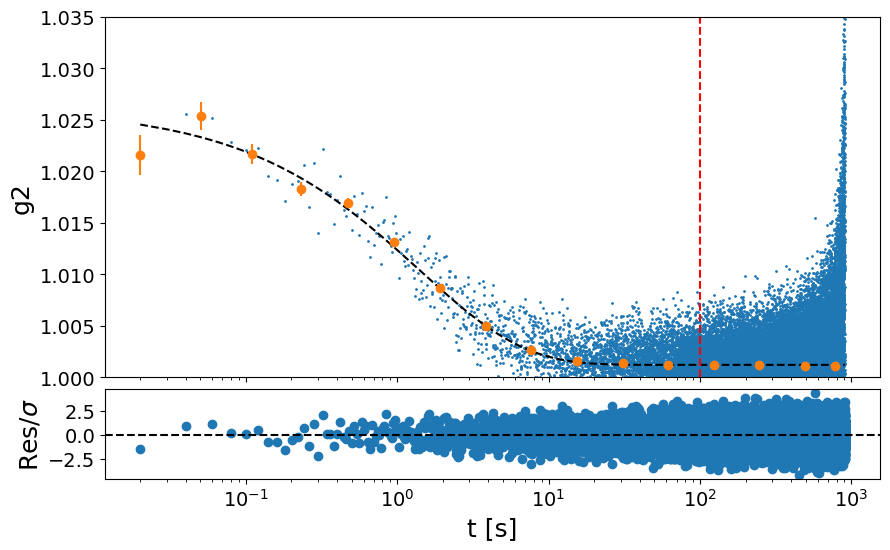

In [ ]:
##################
t1_fit = None
t2_fit = 1e2
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

# XPCS scan: T=590C, Q=0.19, 20min @ 20ms (60000fm) (GeO2_6, dataset 1, scan 1) 

In [ ]:
#######################################
sample_name = 'GeO2_6_590C'
Ndataset = 1
Nscan = 3
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4*20)

#############################
command = mtimescan 0.02 1 60000
Ei = 9.699998837562536
itime = 0.020101
theta = 1.7500000000000004
Q = 0.15
T = 20.10 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/12 loo

### Flux check

################################################################################
Maximum count in the whole run -> 78.0
################################################################################



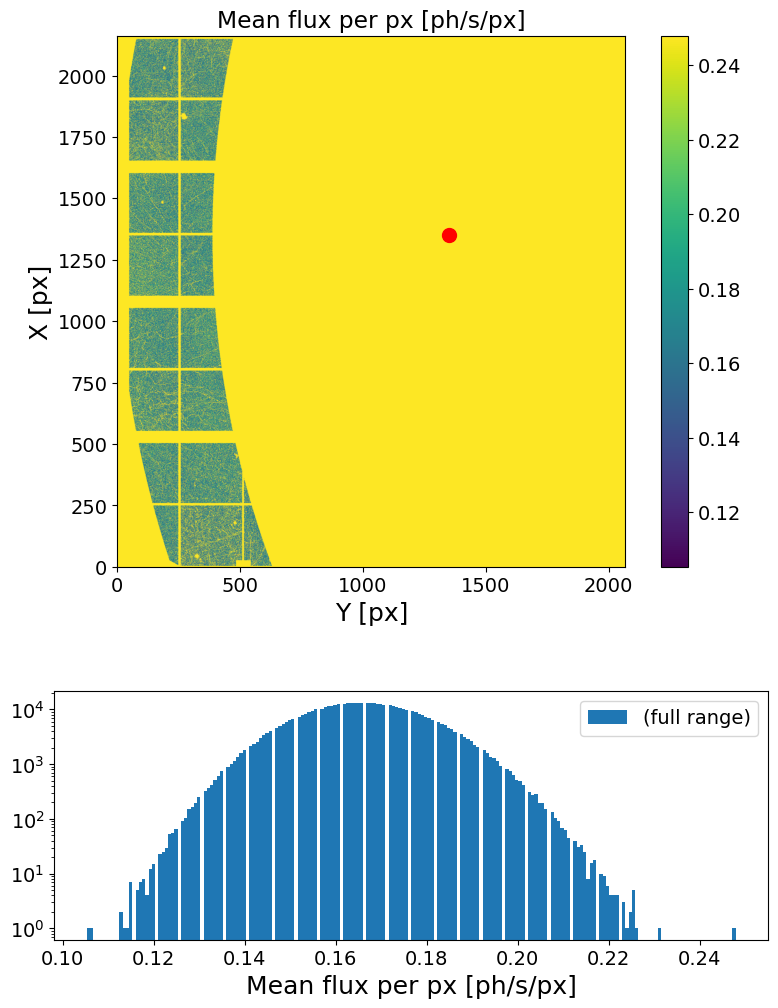

In [ ]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [ ]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

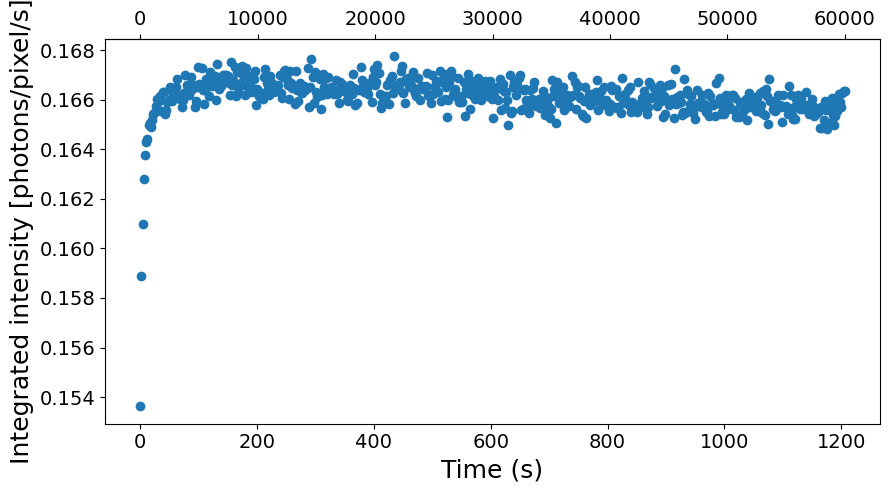

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [ ]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=15000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...


Done! (elapsed time = 0.77 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 6.33 s)
	 | 44999 X 44999 squared matrix
	 | memory usage (np.array @ float32) = 7.543 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 1.04 s)

Computing g2 (using cython code)...
Done! (elapsed time = 1.55 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,0.57681,0.081305,14.095664,0.647257,0.051903,8.018864,0.025304,0.001888,7.459325,1.001267,0.000043,0.00429,0.963907


/tmp/ipykernel_127908/3681683624.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


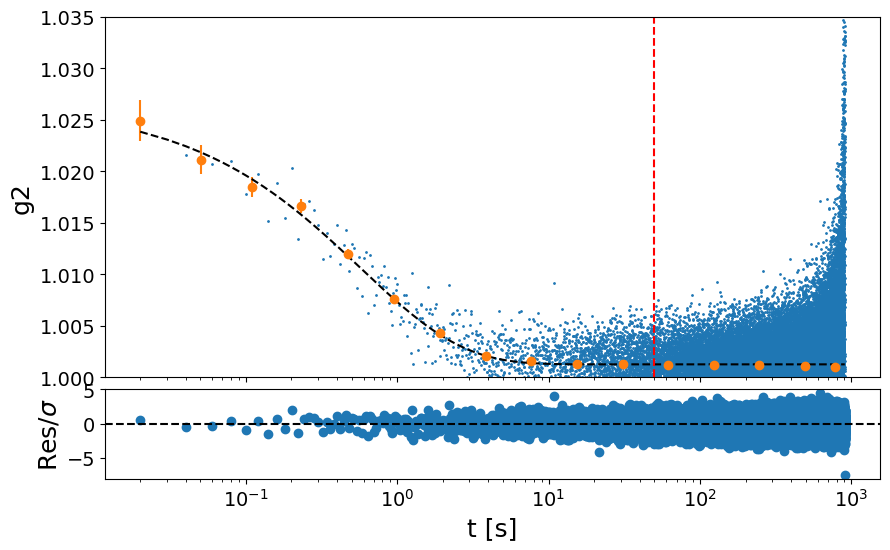

In [ ]:
##################
t1_fit = None
t2_fit = 5e1
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

# XPCS scan: T=660C, Q=0.19, 20min @ 20ms (60000fm) (GeO2_6, dataset 1, scan 1)

In [ ]:
#######################################
sample_name = 'GeO2_6_660C'
Ndataset = 1
Nscan = 1
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4*20)

#############################
command = mtimescan 0.02 1 60000
Ei = 9.699998837562536
itime = 0.020101
theta = 1.7500000000000004
Q = 0.15
T = 20.10 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/12 loo

Done! (elapsed time = 7.47 s)
Concatenating vectors ...
Done! (elapsed time = 0.51 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_6_660C/GeO2_6_660C_0001/scan0001/
	 | Shape:       (59999, 523950)
	 | Sparsity:     3.2e-03
	 | Memory usage (scipy.csr_array): 1.132 GB (np.array usage: 117.110 GB)
Filtering gamma ray signal (i.e. signals over treshold) ...
Done! (elapsed time = 0.61 s)
Removing gamma ray signal (set 0s) ...
Done! (elapsed time = 1.03 s)


### Flux check

################################################################################
Maximum count in the whole run -> 79.0
################################################################################



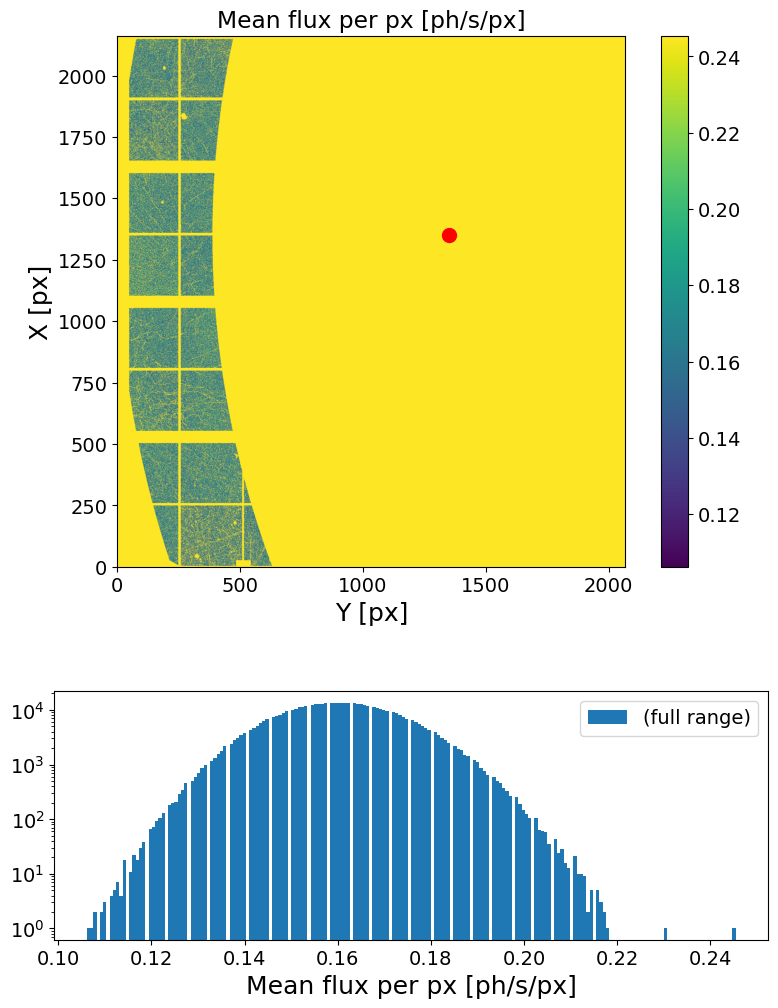

In [ ]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [ ]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

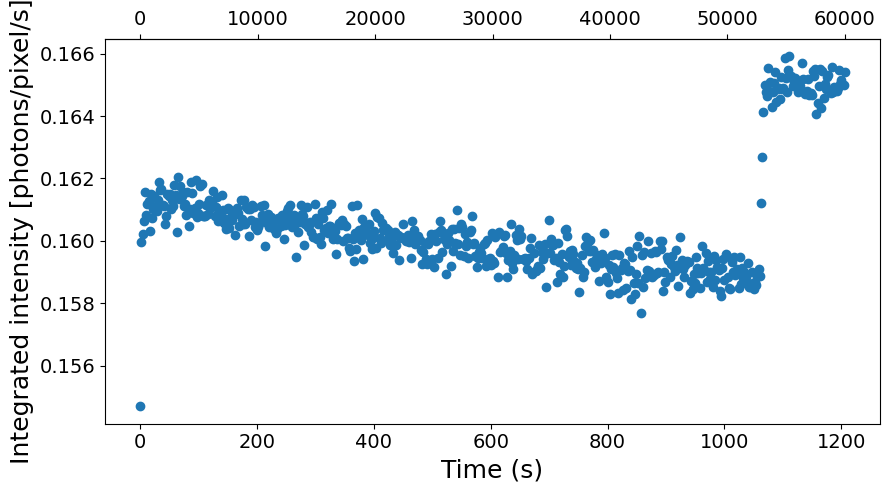

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [ ]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=10000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...


Done! (elapsed time = 0.69 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 7.07 s)
	 | 49999 X 49999 squared matrix
	 | memory usage (np.array @ float32) = 9.313 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 1.19 s)

Computing g2 (using cython code)...
Done! (elapsed time = 2.3 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,0.242265,0.061673,25.456978,0.614196,0.078726,12.81767,0.026945,0.003557,13.201895,1.001172,0.000042,0.004198,1.056885


/tmp/ipykernel_127908/207430431.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


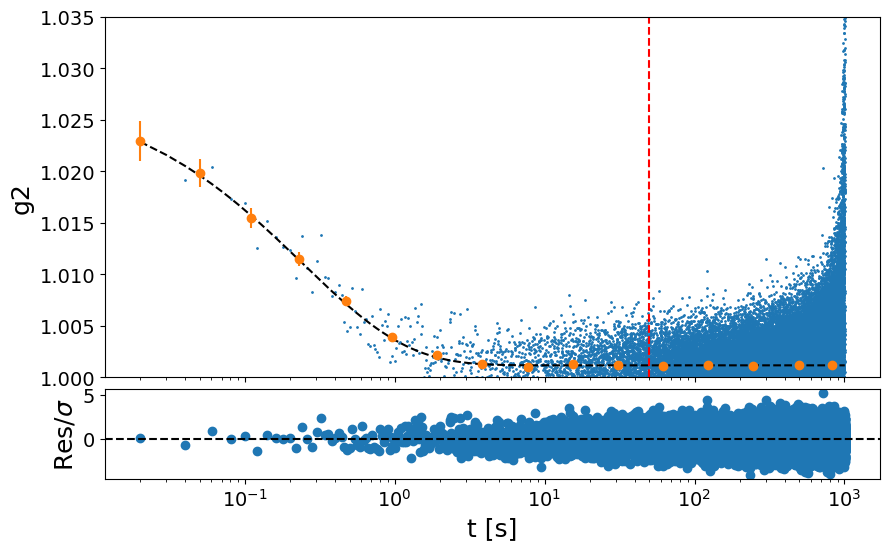

In [ ]:
##################
t1_fit = None
t2_fit = 5e1
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=False)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

# XPCS scan: T=730C, Q = 0.19, 7min @ 2ms (200000fm) (GeO2_6, dataset 1, scan 1) 

In [ ]:
#######################################
sample_name = 'GeO2_6_730C'
Ndataset = 1
Nscan = 3
Nfi, Nff = 10, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4*2)

#############################
command = mtimescan 0.002 1 199804
Ei = 9.699998837562536
itime = 0.0021
theta = 1.7500000000000004
Q = 0.15
T = 6.99 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/40 loop

### Flux check

################################################################################
Maximum count in the whole run -> 6.0
################################################################################



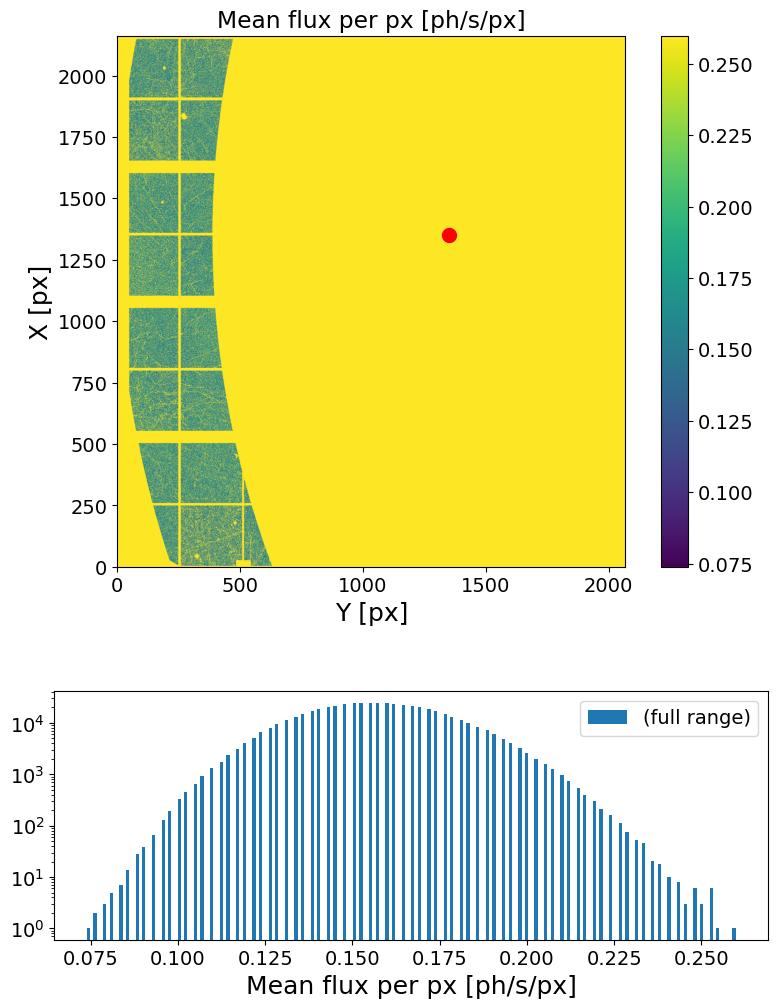

In [ ]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [ ]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

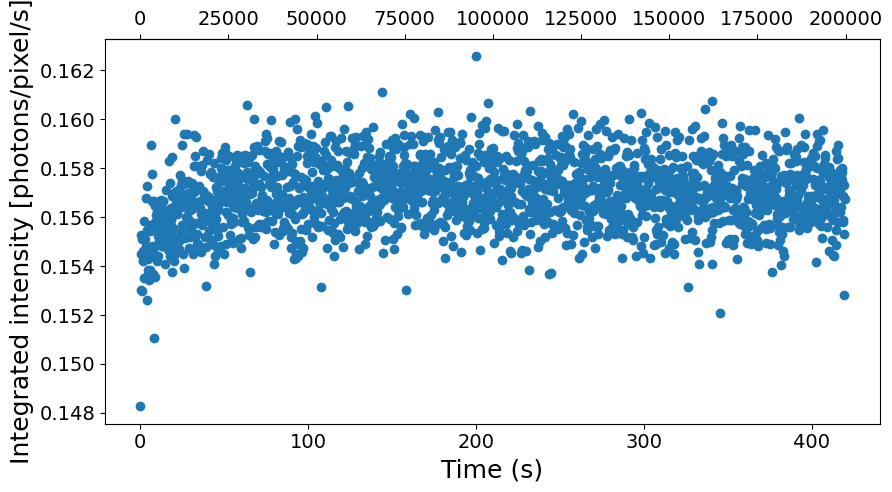

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [ ]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=50000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...
Done! (elapsed time = 0.27 s)
Computing G2t (using MKL library)...


Done! (elapsed time = 7.93 s)
	 | 149794 X 149794 squared matrix
	 | memory usage (np.array @ float32) = 83.589 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 8.49 s)

Computing g2 (using cython code)...
Done! (elapsed time = 16.49 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,0.058096,0.037286,64.1807,0.637944,0.224766,35.232813,0.032859,0.011009,33.504645,1.001076,0.000167,0.016712,1.001689


/tmp/ipykernel_127908/342003680.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


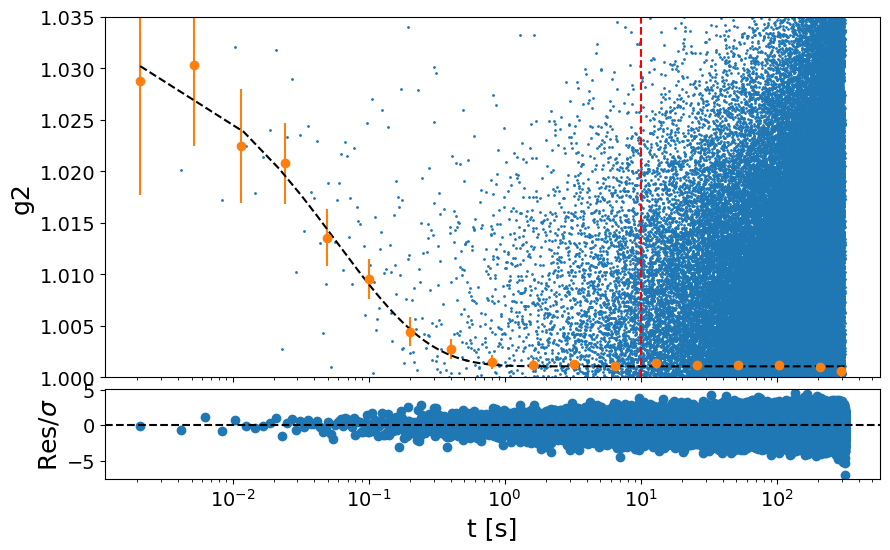

In [ ]:
##################
t1_fit = None
t2_fit = 1e1
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=False)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

#  XPCS scan: T=660C, Q=0.19, 7min @ 2ms (200000fm) (GeO2_6, dataset 2, scan 1) 

In [ ]:
#######################################
sample_name = 'GeO2_6_660C'
Ndataset = 2
Nscan = 3
Nfi, Nff = None, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4*2)

#############################
command = mtimescan 0.002 1 199804
Ei = 9.699998837562536
itime = 0.0021
theta = 1.7500000000000004
Q = 0.15
T = 6.99 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/40 loop

### Flux check

################################################################################
Maximum count in the whole run -> 6.0
################################################################################



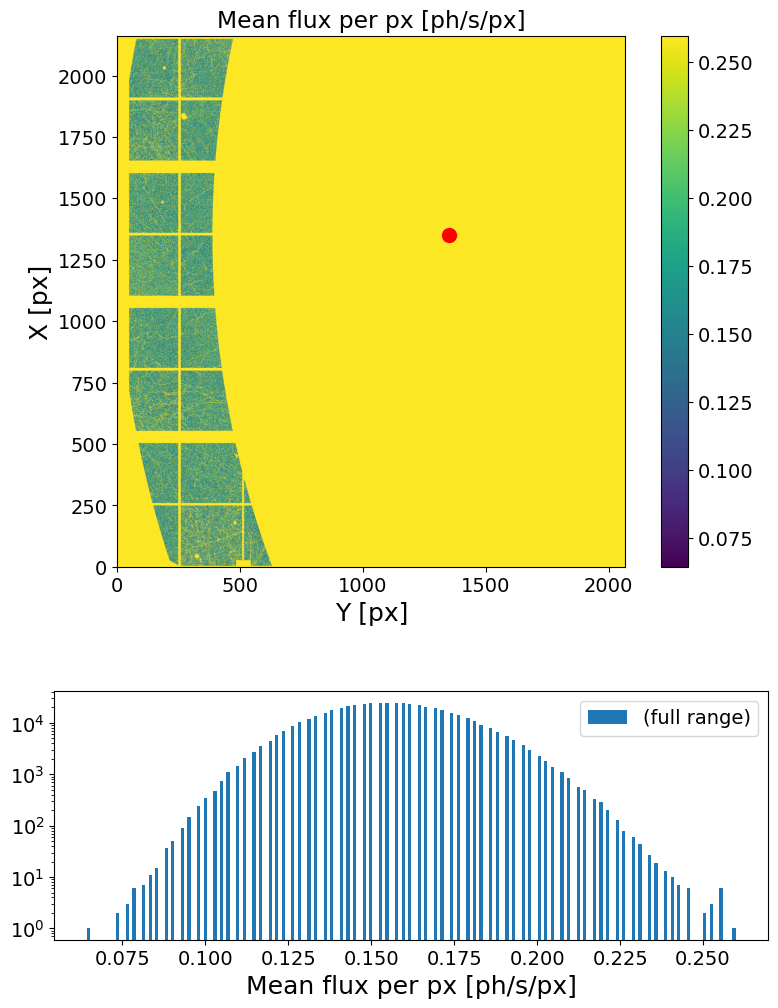

In [ ]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [ ]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

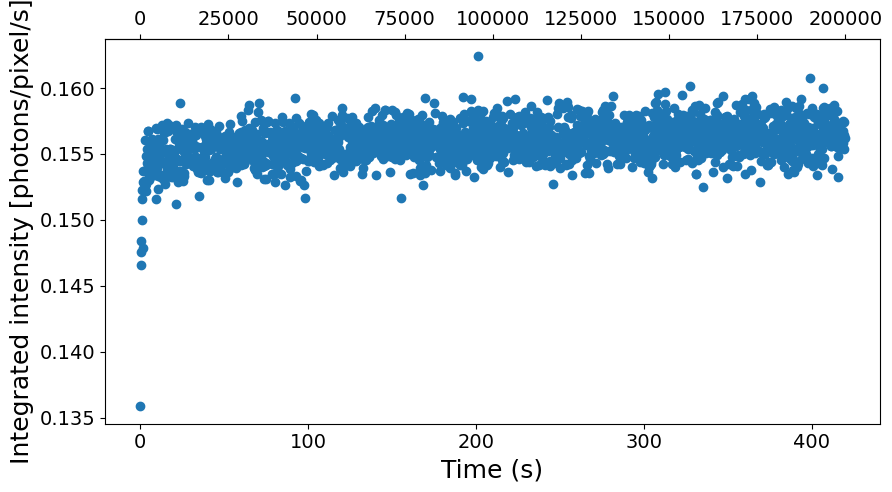

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [ ]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=50000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...
Done! (elapsed time = 0.25 s)
Computing G2t (using MKL library)...


Done! (elapsed time = 7.88 s)
	 | 149804 X 149804 squared matrix
	 | memory usage (np.array @ float32) = 83.6 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 8.4 s)

Computing g2 (using cython code)...
Done! (elapsed time = 16.85 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,0.084055,0.072435,86.175671,0.378939,0.083747,22.100331,0.036528,0.011588,31.723955,1.001103,0.000086,0.008631,0.992528


/tmp/ipykernel_127908/207430431.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


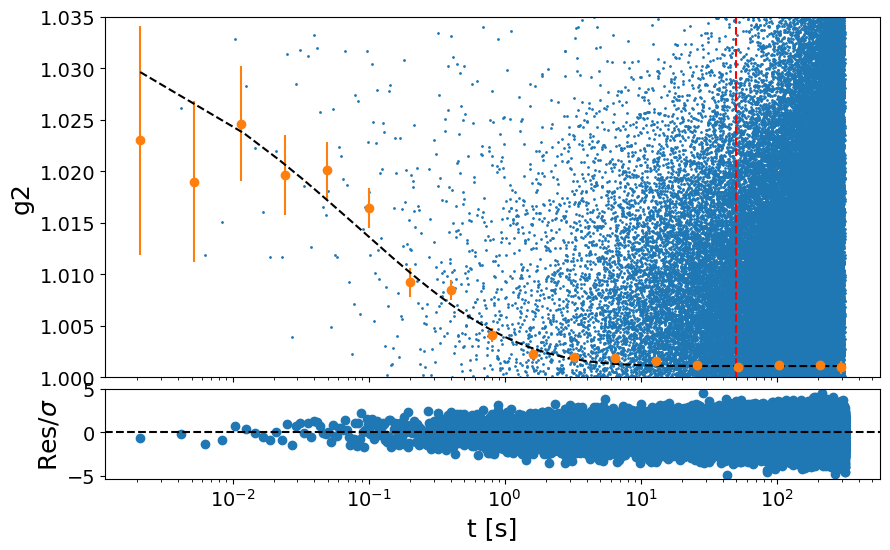

In [ ]:
##################
t1_fit = None
t2_fit = 5e1
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=False)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

# XPCS scan: T=590C, Q=0.19, 7min @ 2ms (200000fm) (GeO2_6, dataset 2, scan 1) 

In [ ]:
#######################################
sample_name = 'GeO2_6_590C'
Ndataset = 2
Nscan = 3
Nfi, Nff = 10, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4*2)

#############################
command = mtimescan 0.002 1 199804
Ei = 9.699998837562536
itime = 0.0021
theta = 1.7500000000000004
Q = 0.15
T = 6.99 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/40 loop

	 -> loading file eiger4m_v2_sparse_frame_0_00020.h5 (21/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00021.h5 (22/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00022.h5 (23/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00023.h5 (24/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00024.h5 (25/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00025.h5 (26/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00026.h5 (27/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00027.h5 (28/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00028.h5 (29/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00029.h5 (30/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00030.h5 (31/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00031.h5 (32/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00032.h5 (33/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00033.h5 (34/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00034.h5 (35/40 lo

### Flux check

################################################################################
Maximum count in the whole run -> 5.0
################################################################################



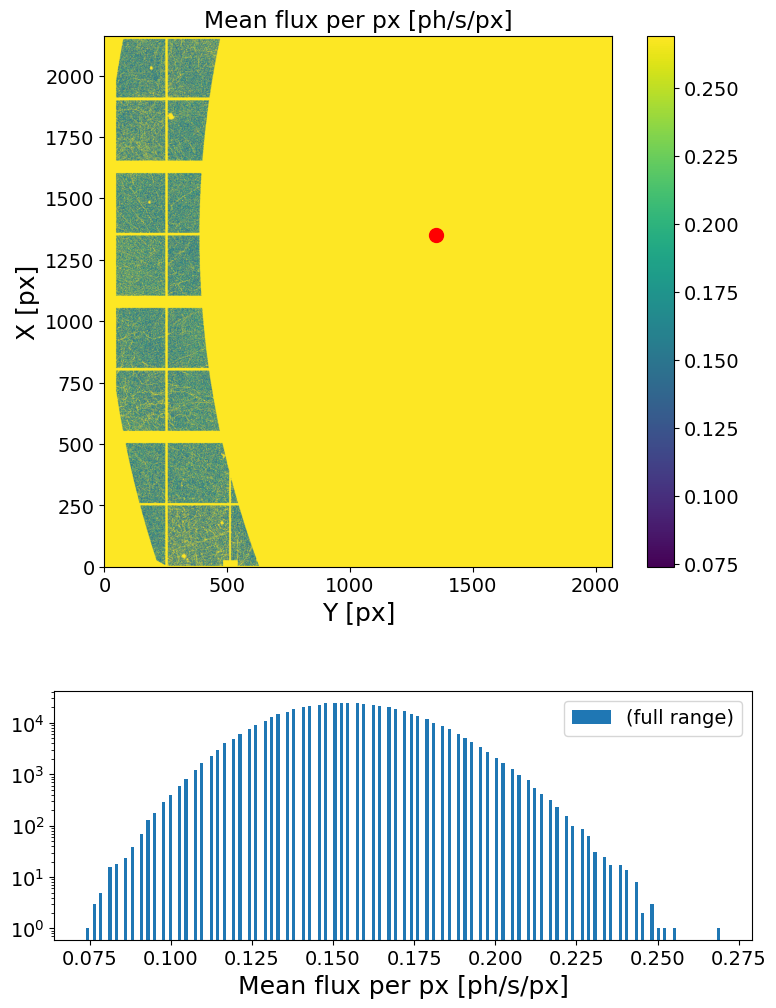

In [ ]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [ ]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

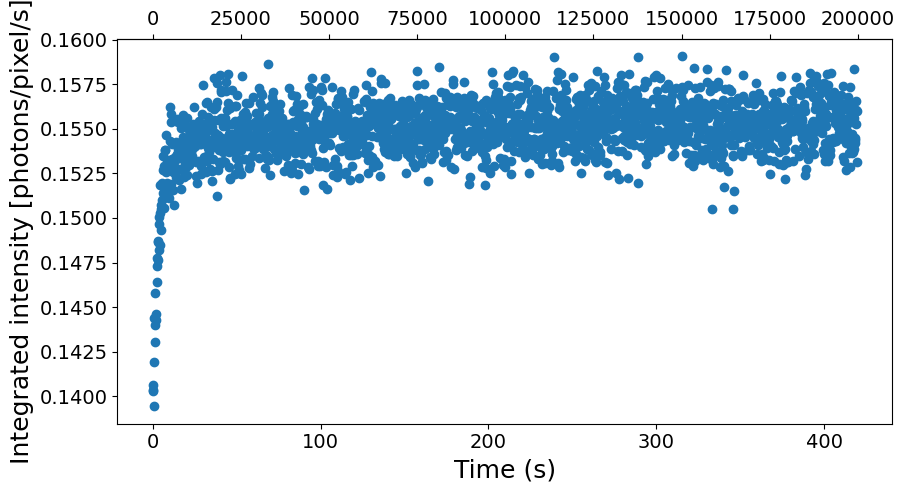

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [ ]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=50000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...
Done! (elapsed time = 0.23 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 7.78 s)
	 | 149794 X 149794 squared matrix
	 | memory usage (np.array @ float32) = 83.589 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 8.33 s)

Computing g2 (using cython code)...
Done! (elapsed time = 16.3 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,0.267667,0.105148,39.283369,0.468005,0.063994,13.673838,0.034237,0.005626,16.43371,1.001,0.000042,0.004203,0.997887


/tmp/ipykernel_127908/460136879.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


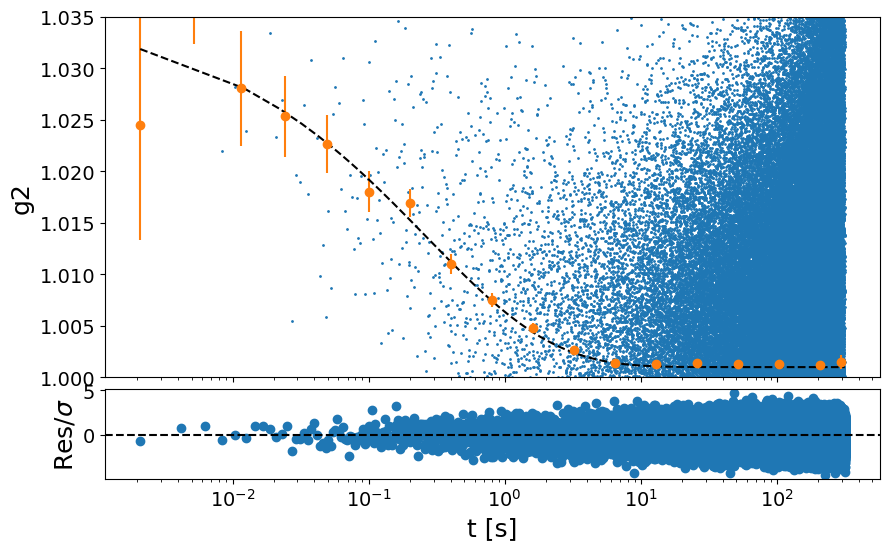

In [ ]:
##################
t1_fit = None
t2_fit = 1e2
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=False)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()